# TP2 - Classification du dataset Heart Disease UCI

Ce notebook suit l'ordre demandé dans le TP: préparation des données, étude exploratoire, puis classification binaire selon la variable cible `disease` avec plusieurs algorithmes (Naive Bayes, Régression logistique, k-NN, SVM, LDA, Arbre de décision).

Les sections incluent:
- les graphiques demandés,
- les recherches d'hyperparamètres,
- les métriques sur train/test,
- des interprétations rédigées.

## Plan du notebook
1. Chargement et informations de base Pandas
2. Création de la variable cible binaire `disease`
3. Étude exploratoire (univariée + bivariée)
4. Split train/test + pipelines de prétraitement
5. Naive Bayes (Gaussian, Categorical, Mixed)
6. Régression logistique
7. k-NN (GridSearch, RandomizedSearch, optimisation imputation)
8. SVM linéaire + SVM à noyau
9. LDA
10. Arbre de décision + représentation Graphviz
11. Synthèse comparative finale

In [34]:
# Imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.naive_bayes import GaussianNB, CategoricalNB
from mixed_naive_bayes import MixedNB

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree

import graphviz

warnings.filterwarnings("ignore")

# Theme visuel clair et propre
sns.set_theme(style="white", context="notebook")
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "savefig.transparent": False,
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
})

# Force le backend inline à exporter avec fond blanc
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("config", "InlineBackend.figure_format = 'retina'")
        ip.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'edgecolor': 'white', 'bbox_inches': 'tight'}"
        )
except Exception:
    pass

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_PATH = Path("Heart Disease (4).csv")
OUT_DIR = Path("outputs")
PLOTS_DIR = OUT_DIR / "plots"
TREES_DIR = OUT_DIR / "trees"

OUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)
TREES_DIR.mkdir(exist_ok=True)

NUMERIC_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

all_results = []

In [39]:
# Fonctions utilitaires
import matplotlib.patches as mpatches


def load_and_prepare(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    df = df.replace("?", np.nan)

    for col in NUMERIC_COLS + CATEGORICAL_COLS + ["num"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["disease"] = (df["num"] > 0).astype(int)
    return df


def build_base_preprocessor() -> ColumnTransformer:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, NUMERIC_COLS),
        ("cat", cat_pipe, CATEGORICAL_COLS)
    ])


def get_scores(y_true, y_pred, y_score=None):
    d = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
        d["avg_precision"] = average_precision_score(y_true, y_score)
    return d


def get_score_vector(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        vals = model.decision_function(X)
        vals = np.asarray(vals)
        return vals if vals.ndim == 1 else None
    return None


def quick_interpretation(name, s_train, s_test):
    gap_f1 = s_train["f1"] - s_test["f1"]
    roc_txt = f", ROC-AUC test={s_test['roc_auc']:.3f}" if "roc_auc" in s_test else ""

    if s_test["f1"] >= 0.88:
        perf = "performance excellente"
    elif s_test["f1"] >= 0.82:
        perf = "performance solide"
    elif s_test["f1"] >= 0.75:
        perf = "performance correcte"
    else:
        perf = "performance à améliorer"

    if gap_f1 > 0.08:
        gen = "possible surapprentissage (écart train/test notable)"
    elif gap_f1 < -0.03:
        gen = "test meilleur que train (possible variance d'échantillonnage)"
    else:
        gen = "bonne généralisation (écart train/test maîtrisé)"

    print(f"Interpretation - {name}: {perf}; F1 test={s_test['f1']:.3f}{roc_txt}; {gen}.")


def evaluate_pipeline(name, model, X_train, y_train, X_test, y_test, show_reports=True, plot_curves=True):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    y_score_train = get_score_vector(model, X_train)
    y_score_test = get_score_vector(model, X_test)

    s_train = get_scores(y_train, y_pred_train, y_score_train)
    s_test = get_scores(y_test, y_pred_test, y_score_test)

    print(f"\n===== {name} =====")
    print("Train:", {k: round(v, 4) for k, v in s_train.items()})
    print("Test :", {k: round(v, 4) for k, v in s_test.items()})

    if show_reports:
        print("\nClassification report (test):")
        print(classification_report(y_test, y_pred_test, digits=4))

        cm = confusion_matrix(y_test, y_pred_test)
        fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=130, facecolor="white")
        ax.set_facecolor("white")
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap=sns.light_palette("#1D4ED8", as_cmap=True),
            cbar=False,
            linewidths=1,
            linecolor="#E2E8F0",
            square=True,
            xticklabels=["Pred no_disease", "Pred disease"],
            yticklabels=["True no_disease", "True disease"],
            ax=ax
        )
        ax.set_title(f"Matrice de confusion - {name}", pad=8, fontsize=13, weight="semibold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        fig.savefig(PLOTS_DIR / f"cm_{name}.png", dpi=180, facecolor="white", bbox_inches="tight")
        plt.show()

    if plot_curves and y_score_test is not None:
        fpr, tpr, _ = roc_curve(y_test, y_score_test)
        pr, rc, _ = precision_recall_curve(y_test, y_score_test)

        fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4), dpi=130, facecolor="white")

        axes[0].set_facecolor("white")
        axes[0].plot(fpr, tpr, color="#2563EB", linewidth=2.2, label=f"AUC={s_test.get('roc_auc', np.nan):.3f}")
        axes[0].plot([0, 1], [0, 1], "--", color="#94A3B8", linewidth=1.4)
        axes[0].set_title(f"ROC - {name}", fontsize=13, weight="semibold")
        axes[0].set_xlabel("False Positive Rate")
        axes[0].set_ylabel("True Positive Rate")
        axes[0].grid(alpha=0.10)
        axes[0].legend(frameon=False)

        axes[1].set_facecolor("white")
        axes[1].plot(rc, pr, color="#EA580C", linewidth=2.2, label=f"AP={s_test.get('avg_precision', np.nan):.3f}")
        axes[1].set_title(f"Precision-Recall - {name}", fontsize=13, weight="semibold")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].grid(alpha=0.10)
        axes[1].legend(frameon=False)

        plt.tight_layout()
        fig.savefig(PLOTS_DIR / f"curves_{name}.png", dpi=180, facecolor="white", bbox_inches="tight")
        plt.show()

    quick_interpretation(name, s_train, s_test)

    all_results.append({
        "model": name,
        **{f"train_{k}": v for k, v in s_train.items()},
        **{f"test_{k}": v for k, v in s_test.items()}
    })

    return model, s_train, s_test

## 1) Chargement du dataset et informations de base

In [19]:
df = load_and_prepare(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nTypes des variables:")
display(df.dtypes.to_frame("dtype"))

print("\nValeurs manquantes par colonne:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nStatistiques descriptives (numériques):")
display(df.describe(include=[np.number]).T)

Shape: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0



Types des variables:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Valeurs manquantes par colonne:


,missing
ca,4
thal,2
age,0
trestbps,0
chol,0
sex,0
cp,0
restecg,0
fbs,0
thalach,0



Statistiques descriptives (numériques):


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Interprétation
- Le dataset contient 303 observations.
- Les valeurs manquantes se concentrent surtout sur `ca` et `thal`, ce qui justifie une étape d'imputation dans les pipelines.
- La cible binaire `disease` est créée à partir de `num > 0`.

## 2) Étude exploratoire

,proportion
disease,
0,0.541254
1,0.458746


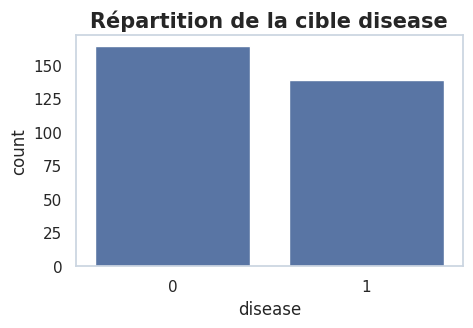

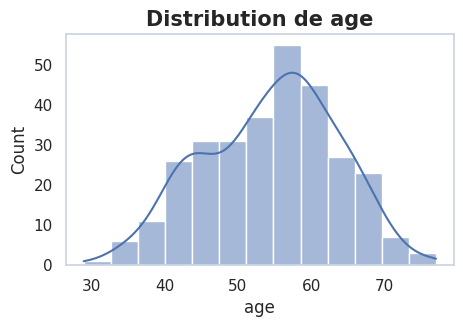

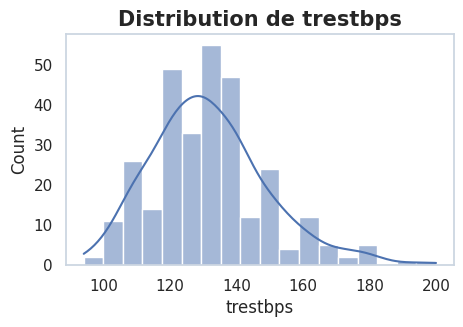

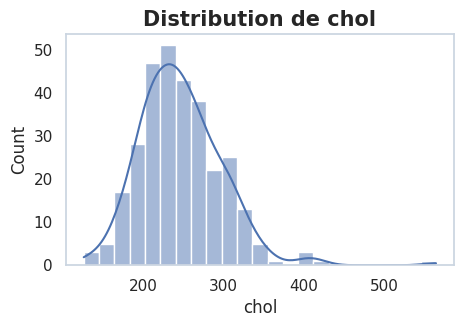

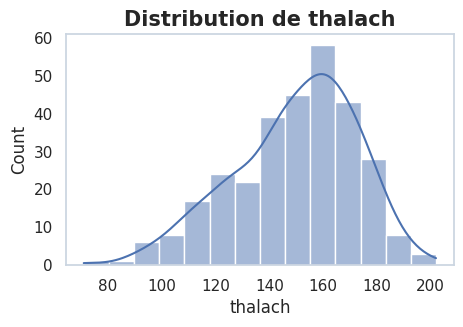

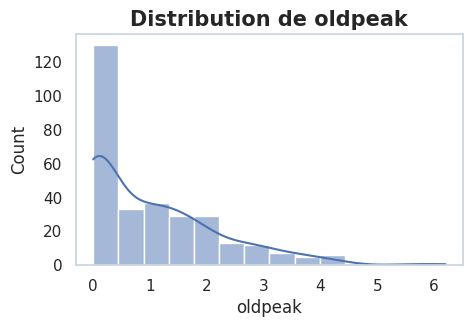

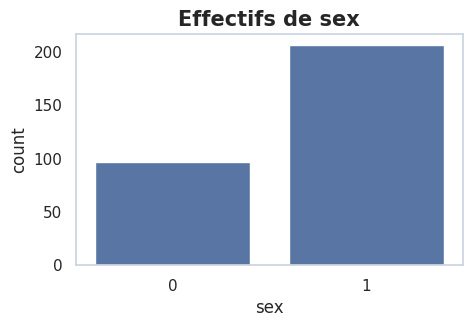

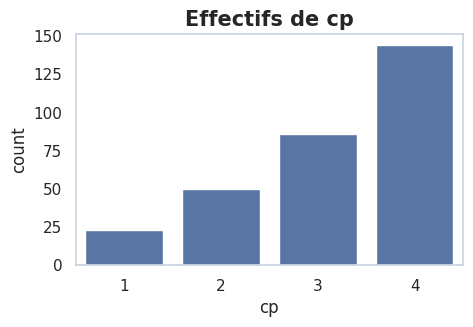

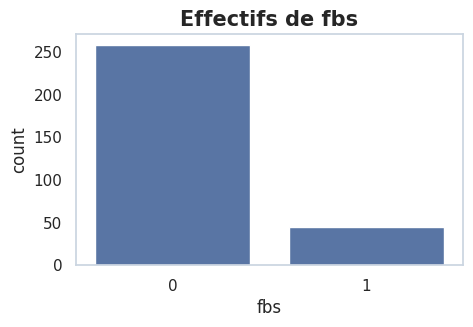

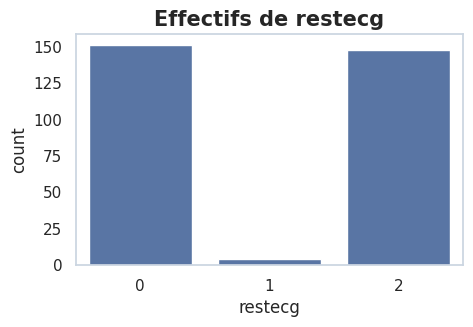

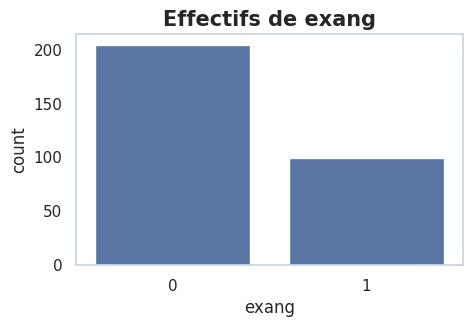

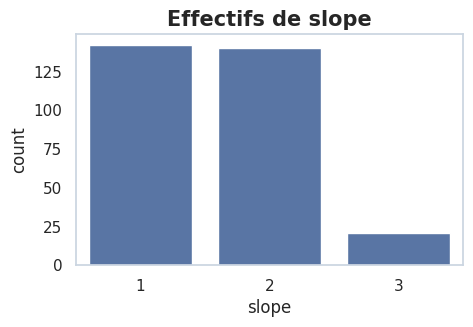

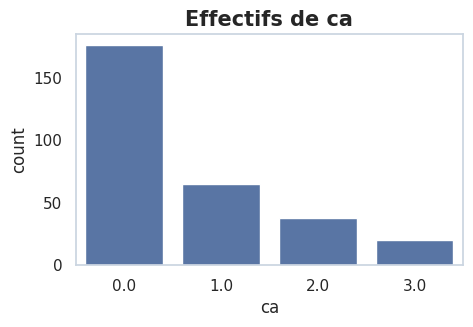

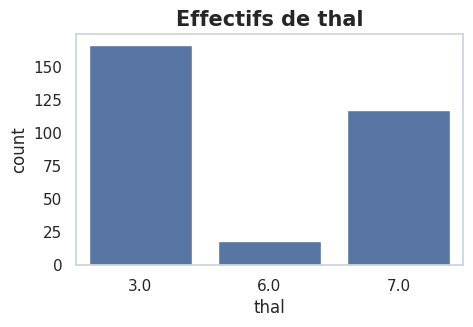

In [20]:
# Distribution de la cible
target_dist = df["disease"].value_counts(normalize=True).rename("proportion")
display(target_dist.to_frame())

plt.figure(figsize=(5, 3))
sns.countplot(x=df["disease"])
plt.title("Répartition de la cible disease")
plt.show()

# Etude univariée des variables numériques
for col in NUMERIC_COLS:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

# Etude univariée des variables qualitatives
for col in CATEGORICAL_COLS:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Effectifs de {col}")
    plt.show()

Moyennes des variables numériques selon disease:


disease,0,1
age,52.585366,56.625899
trestbps,129.250000,134.568345
chol,242.640244,251.474820
thalach,158.378049,139.258993
oldpeak,0.586585,1.574101


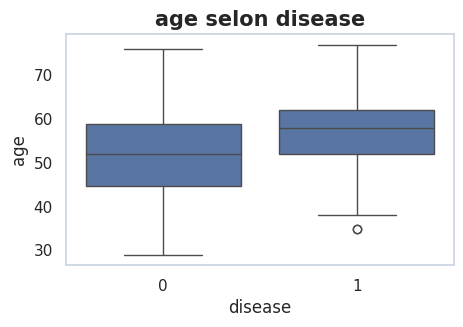

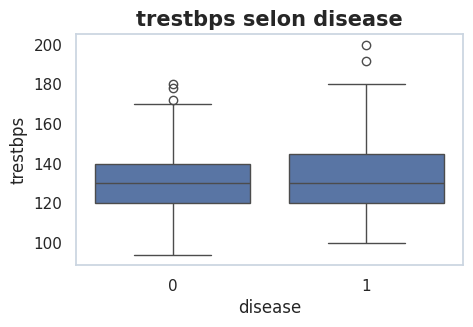

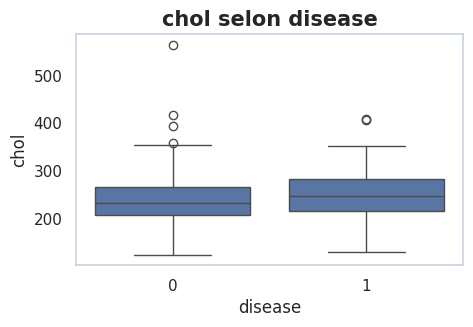

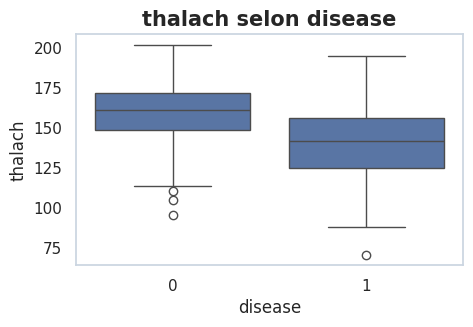

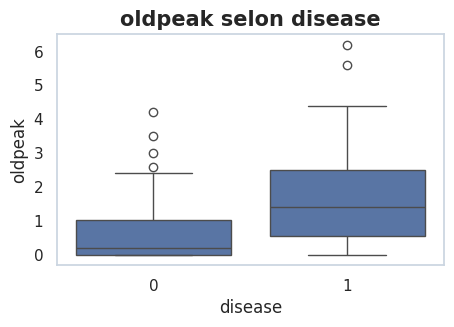


Table croisée normalisée: sex vs disease


disease,0,1
sex,,
0,0.742268,0.257732
1,0.446602,0.553398


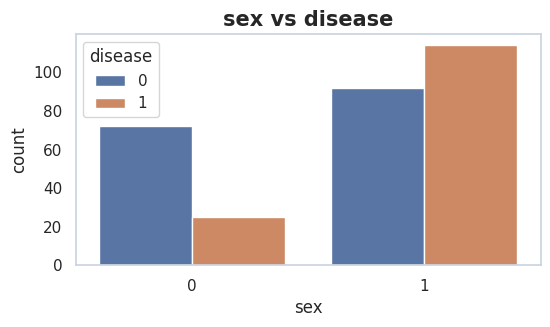


Table croisée normalisée: cp vs disease


disease,0,1
cp,,
1,0.695652,0.304348
2,0.820000,0.180000
3,0.790698,0.209302
4,0.270833,0.729167


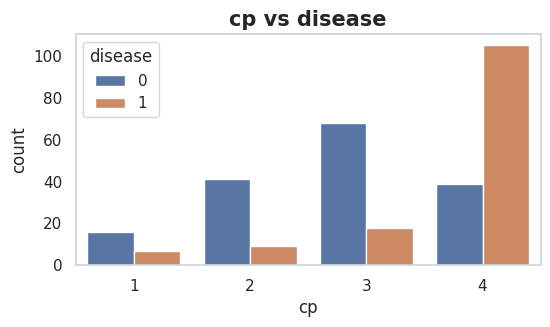


Table croisée normalisée: fbs vs disease


disease,0,1
fbs,,
0,0.546512,0.453488
1,0.511111,0.488889


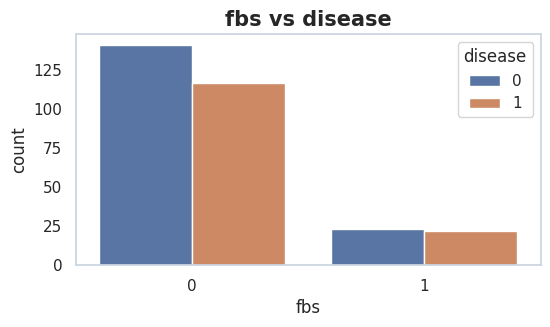


Table croisée normalisée: restecg vs disease


disease,0,1
restecg,,
0,0.629139,0.370861
1,0.250000,0.750000
2,0.459459,0.540541


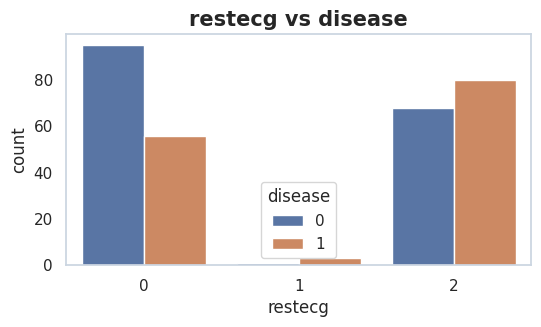


Table croisée normalisée: exang vs disease


disease,0,1
exang,,
0,0.691176,0.308824
1,0.232323,0.767677


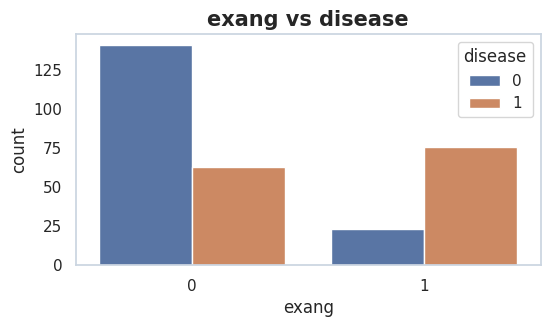


Table croisée normalisée: slope vs disease


disease,0,1
slope,,
1,0.746479,0.253521
2,0.350000,0.650000
3,0.428571,0.571429


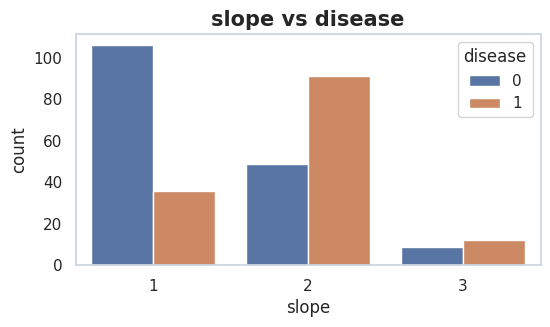


Table croisée normalisée: ca vs disease


disease,0,1
ca,,
0.0,0.738636,0.261364
1.0,0.323077,0.676923
2.0,0.184211,0.815789
3.0,0.150000,0.850000


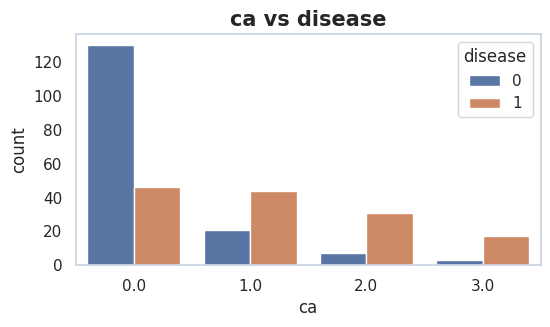


Table croisée normalisée: thal vs disease


disease,0,1
thal,,
3.0,0.777108,0.222892
6.0,0.333333,0.666667
7.0,0.239316,0.760684


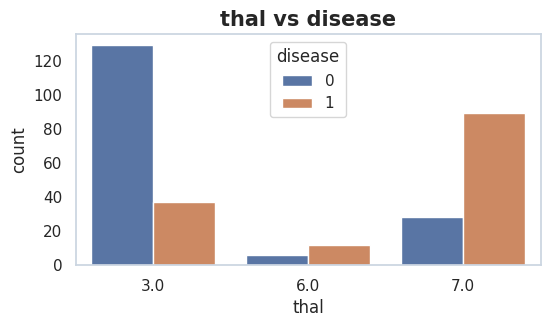

In [21]:
# Étude conjointe avec disease
print("Moyennes des variables numériques selon disease:")
display(df.groupby("disease")[NUMERIC_COLS].mean().T)

for col in NUMERIC_COLS:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=df, x="disease", y=col)
    plt.title(f"{col} selon disease")
    plt.show()

for col in CATEGORICAL_COLS:
    print(f"\nTable croisée normalisée: {col} vs disease")
    display(pd.crosstab(df[col], df["disease"], normalize="index"))

    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, hue="disease")
    plt.title(f"{col} vs disease")
    plt.show()

## 2bis) Matrice de corrélation

Cette section ajoute explicitement la corrélation (demandée) entre variables numériques et la cible binaire `disease`.

,age,trestbps,chol,thalach,oldpeak,disease
age,1.000000,0.284946,0.208950,-0.393806,0.203805,0.223120
trestbps,0.284946,1.000000,0.130120,-0.045351,0.189171,0.150825
chol,0.208950,0.130120,1.000000,-0.003432,0.046564,0.085164
thalach,-0.393806,-0.045351,-0.003432,1.000000,-0.343085,-0.417167
oldpeak,0.203805,0.189171,0.046564,-0.343085,1.000000,0.424510
disease,0.223120,0.150825,0.085164,-0.417167,0.424510,1.000000


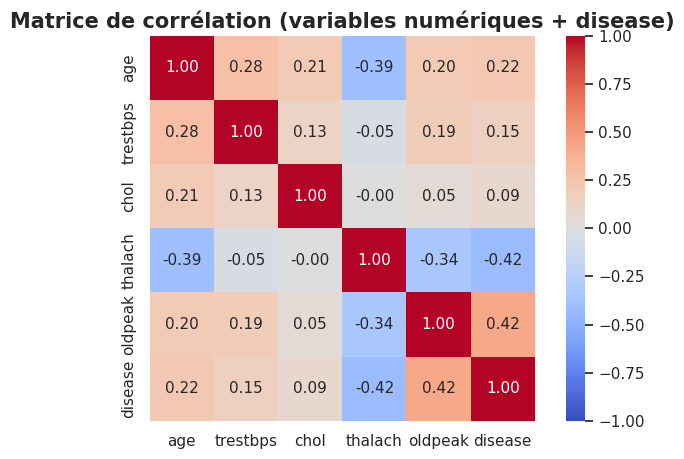

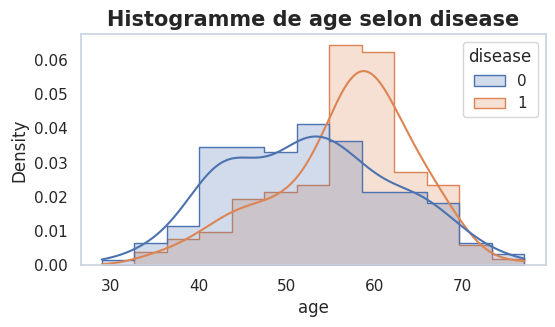

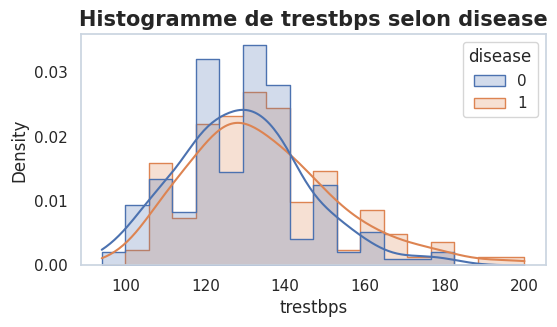

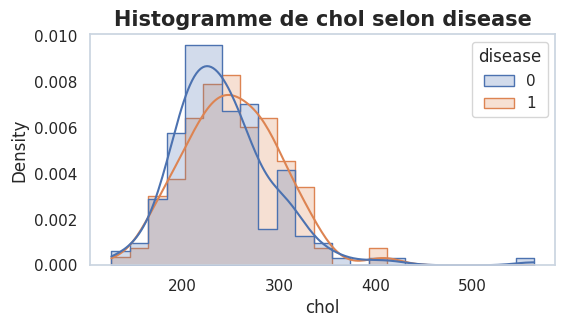

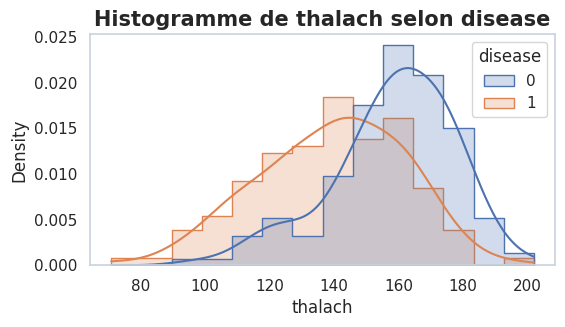

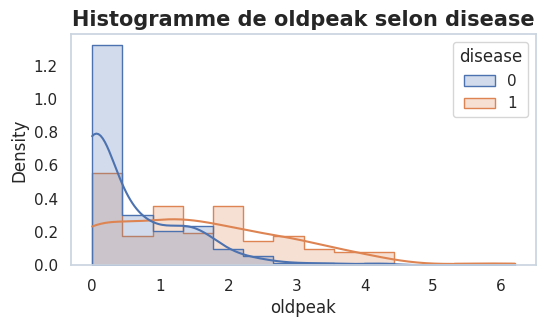

In [22]:
corr_cols = NUMERIC_COLS + ["disease"]
corr_matrix = df[corr_cols].corr(numeric_only=True)

display(corr_matrix)

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Matrice de corrélation (variables numériques + disease)")
plt.show()

# Histogrammes par classe (overlay) pour visualiser les différences entre classes
for col in NUMERIC_COLS:
    plt.figure(figsize=(6, 3))
    sns.histplot(data=df, x=col, hue="disease", kde=True, element="step", stat="density", common_norm=False)
    plt.title(f"Histogramme de {col} selon disease")
    plt.show()

### Interprétation Naive Bayes
- Modèles entraînés: `GaussianNB` (quantitatives), `CategoricalNB` (qualitatives), `MixedNB` (mixte).
- Analyse: comparaison via accuracy, precision, recall, F1, ROC-AUC et courbes ROC/PR.
- Lecture pratique: si `MixedNB` domine sur F1 test et ROC-AUC, il est à privilégier pour ce dataset mixte.
- Point méthodologique: cette section montre l'intérêt de séparer ou combiner les types de variables selon l'algorithme.

## 3) Split train/test et préprocesseurs

In [23]:
X = df[NUMERIC_COLS + CATEGORICAL_COLS]
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

base_prep = build_base_preprocessor()

X_train: (242, 13) | y_train: (242,)
X_test : (61, 13) | y_test : (61,)


### Interprétation Régression Logistique
- Modèle entraîné avec `GridSearchCV` (réglage de `C`, `solver`, `class_weight`).
- Analyse: robustesse évaluée par l'écart train/test et la qualité de séparation (ROC-AUC).
- Lecture pratique: modèle très pertinent si l'objectif est un bon compromis performance + interprétabilité clinique.
- Décision: à retenir comme baseline forte et explicable.


===== gaussian_nb_numeric_only =====
Train: {'accuracy': 0.7107, 'precision': 0.7253, 'recall': 0.5946, 'f1': 0.6535, 'roc_auc': 0.7878, 'avg_precision': 0.7676}
Test : {'accuracy': 0.8197, 'precision': 0.7742, 'recall': 0.8571, 'f1': 0.8136, 'roc_auc': 0.8615, 'avg_precision': 0.872}

Classification report (test):
              precision    recall  f1-score   support

           0     0.8667    0.7879    0.8254        33
           1     0.7742    0.8571    0.8136        28

    accuracy                         0.8197        61
   macro avg     0.8204    0.8225    0.8195        61
weighted avg     0.8242    0.8197    0.8200        61



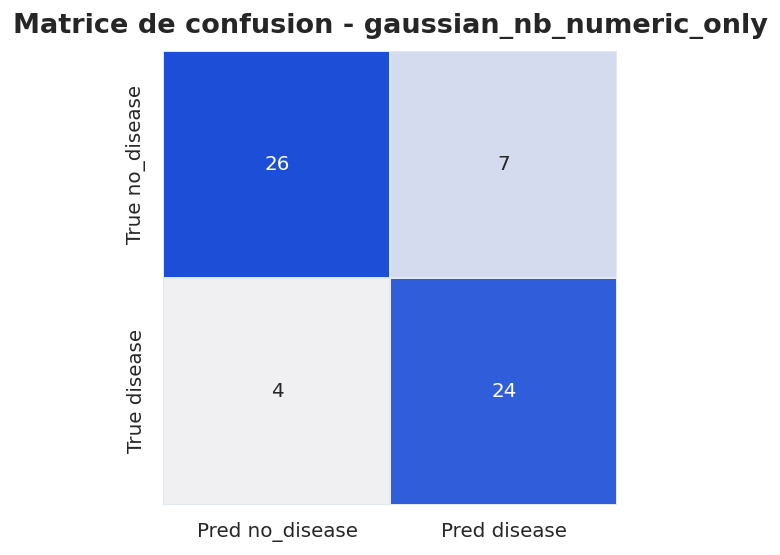

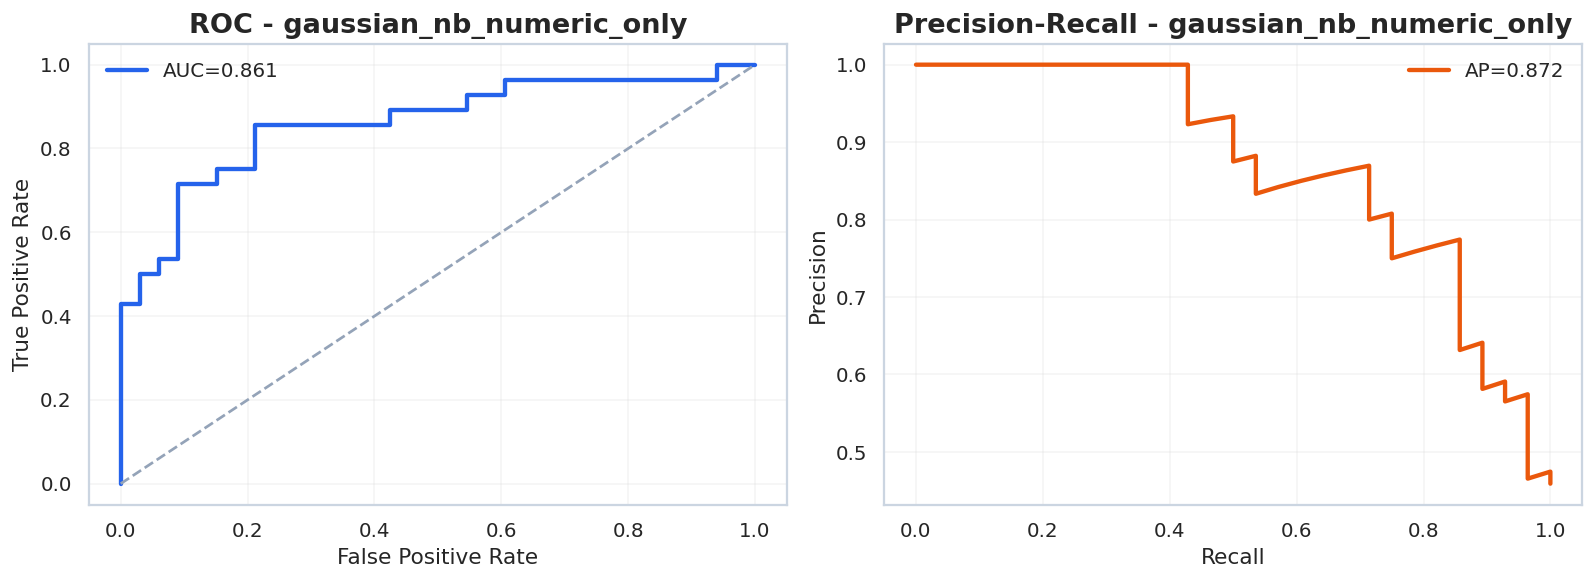

Interpretation - gaussian_nb_numeric_only: performance correcte; F1 test=0.814, ROC-AUC test=0.861; test meilleur que train (possible variance d'échantillonnage).

===== categorical_nb_qualitative_only =====
Train: {'accuracy': 0.8264, 'precision': 0.8108, 'recall': 0.8108, 'f1': 0.8108, 'roc_auc': 0.9109, 'avg_precision': 0.9039}
Test : {'accuracy': 0.8525, 'precision': 0.8276, 'recall': 0.8571, 'f1': 0.8421, 'roc_auc': 0.9502, 'avg_precision': 0.9492}

Classification report (test):
              precision    recall  f1-score   support

           0     0.8750    0.8485    0.8615        33
           1     0.8276    0.8571    0.8421        28

    accuracy                         0.8525        61
   macro avg     0.8513    0.8528    0.8518        61
weighted avg     0.8532    0.8525    0.8526        61



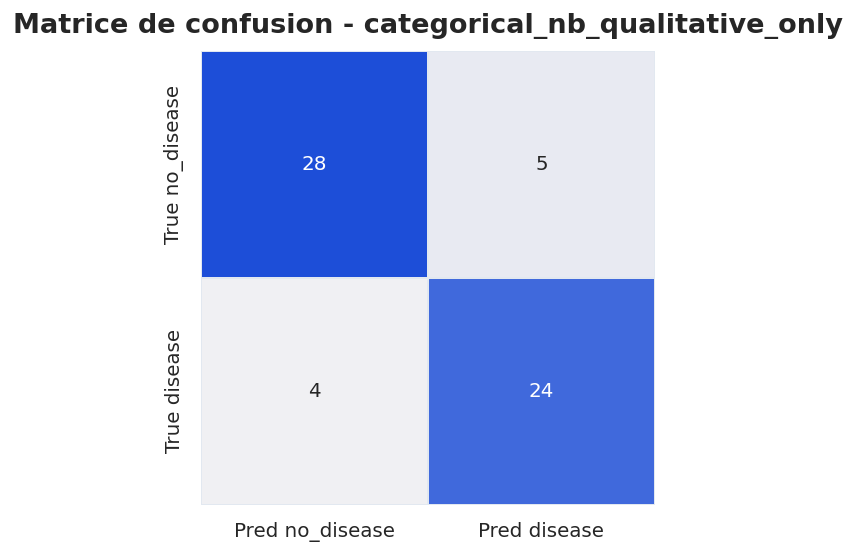

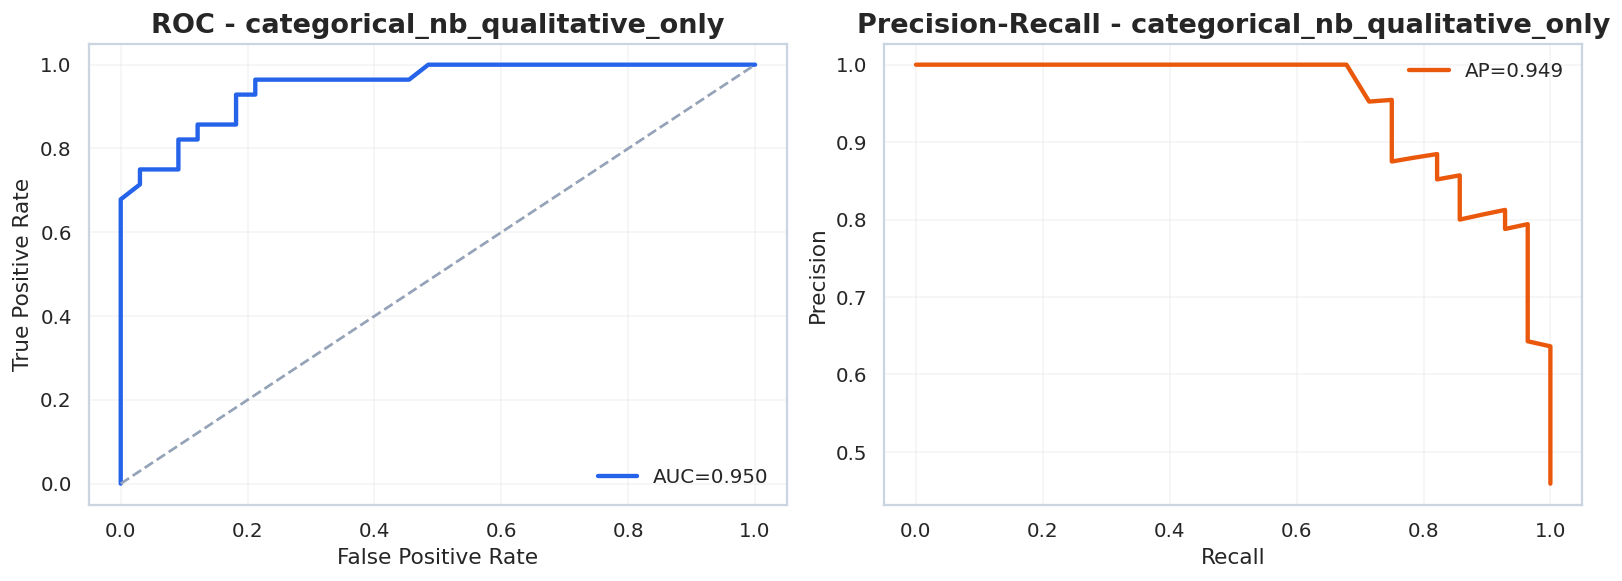

Interpretation - categorical_nb_qualitative_only: performance solide; F1 test=0.842, ROC-AUC test=0.950; test meilleur que train (possible variance d'échantillonnage).

===== mixed_nb_external_module =====
Train: {'accuracy': 0.8388, 'precision': 0.8396, 'recall': 0.8018, 'f1': 0.8203, 'roc_auc': 0.9059, 'avg_precision': 0.887}
Test : {'accuracy': 0.9016, 'precision': 0.8438, 'recall': 0.9643, 'f1': 0.9, 'roc_auc': 0.9773, 'avg_precision': 0.974}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9655    0.8485    0.9032        33
           1     0.8438    0.9643    0.9000        28

    accuracy                         0.9016        61
   macro avg     0.9046    0.9064    0.9016        61
weighted avg     0.9096    0.9016    0.9017        61



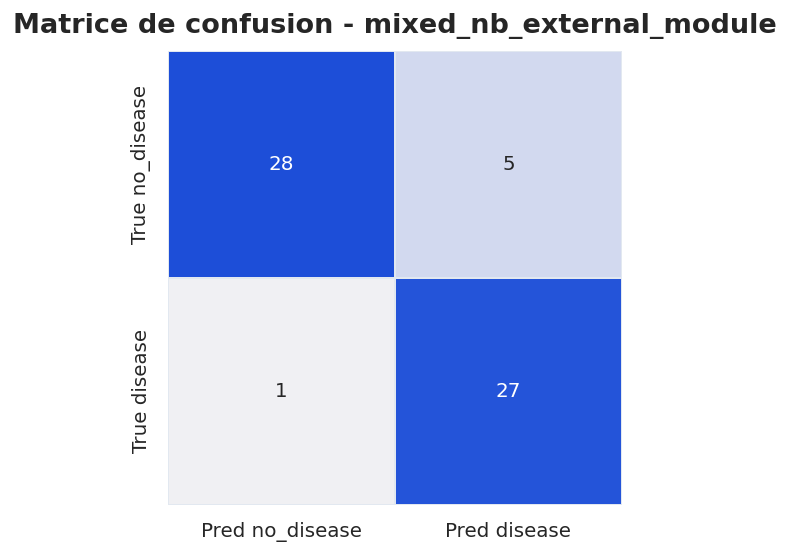

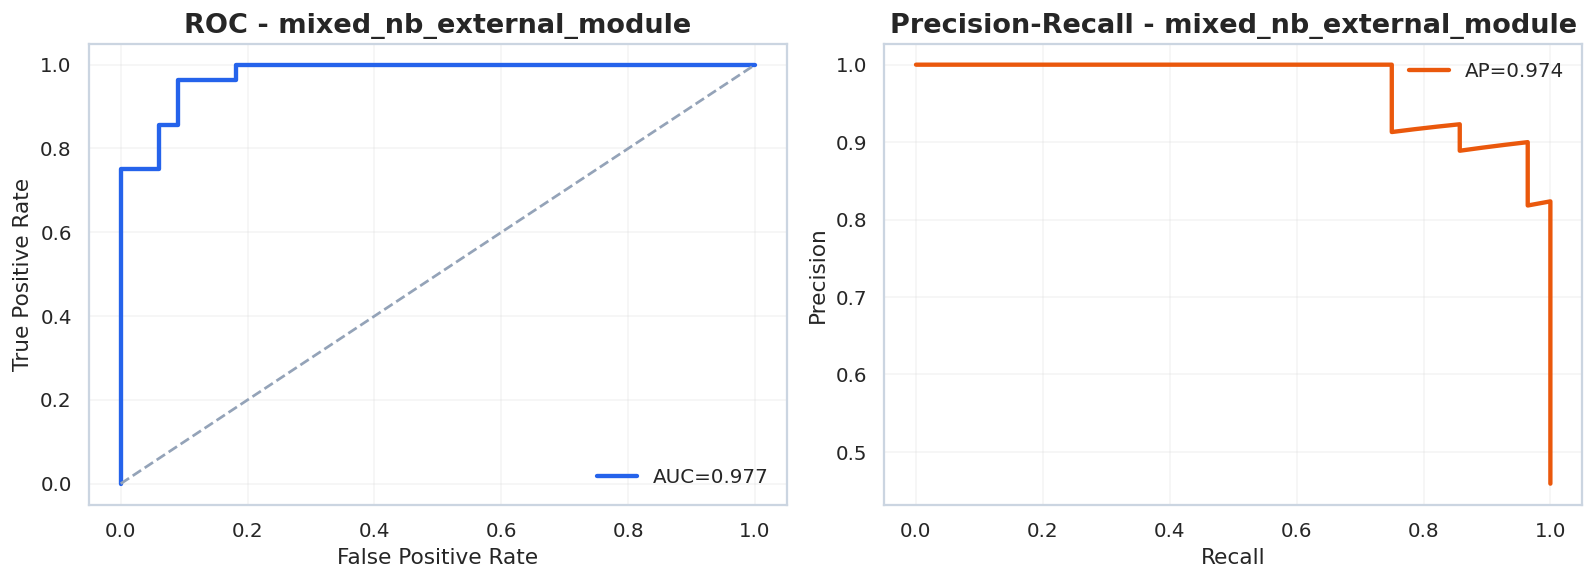

Interpretation - mixed_nb_external_module: performance excellente; F1 test=0.900, ROC-AUC test=0.977; test meilleur que train (possible variance d'échantillonnage).


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['age', 'trestbps', 'chol',
                                                    'thalach', 'oldpeak']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('ordinal',
                                                                    OrdinalEncoder())]),
                                                   ['sex', 'cp', 'fbs',
                                                    'restecg', 'exang', 'slope',
         

In [24]:
# 4.1 Gaussian NB sur variables quantitatives
pre_num = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), NUMERIC_COLS)
], remainder="drop")

gnb_pipe = Pipeline([
    ("prep", pre_num),
    ("model", GaussianNB())
])
evaluate_pipeline("gaussian_nb_numeric_only", gnb_pipe, X_train, y_train, X_test, y_test)

# 4.2 Categorical NB sur variables qualitatives
class SafeCategoricalNB(CategoricalNB):
    def _check_X(self, X):
        X = np.asarray(X)
        X = np.where(X < 0, 0, X)
        return super()._check_X(X)

pre_cat = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), CATEGORICAL_COLS)
], remainder="drop")

cnb_pipe = Pipeline([
    ("prep", pre_cat),
    ("model", SafeCategoricalNB())
])
evaluate_pipeline("categorical_nb_qualitative_only", cnb_pipe, X_train, y_train, X_test, y_test)

# 4.3 Mixed NB (module externe)
class MixedNBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.model = MixedNB(categorical_features=list(range(len(NUMERIC_COLS), len(NUMERIC_COLS)+len(CATEGORICAL_COLS))))

    def fit(self, X, y):
        self.model.fit(X, y)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

mixed_prep = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), NUMERIC_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder())
    ]), CATEGORICAL_COLS),
])

mixed_pipe = Pipeline([
    ("prep", mixed_prep),
    ("model", MixedNBWrapper())
])
evaluate_pipeline("mixed_nb_external_module", mixed_pipe, X_train, y_train, X_test, y_test)

### Interprétation k-NN
- Modèle entraîné avec `GridSearchCV`, puis `RandomizedSearchCV` et optimisation de l'imputation.
- Analyse: impact direct de `n_neighbors`, `weights`, métrique de distance et stratégie d'imputation.
- Lecture pratique: k-NN peut être très performant mais sensible au prétraitement.
- Décision: retenir la version optimisée qui maximise F1 test avec une bonne généralisation.

## 5) Régression logistique (étude complète)

Best params LR: {'model__C': 5, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best CV F1 LR: 0.8268

===== logistic_regression_best =====
Train: {'accuracy': 0.876, 'precision': 0.8785, 'recall': 0.8468, 'f1': 0.8624, 'roc_auc': 0.9319, 'avg_precision': 0.926}
Test : {'accuracy': 0.8689, 'precision': 0.8125, 'recall': 0.9286, 'f1': 0.8667, 'roc_auc': 0.9643, 'avg_precision': 0.9609}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61



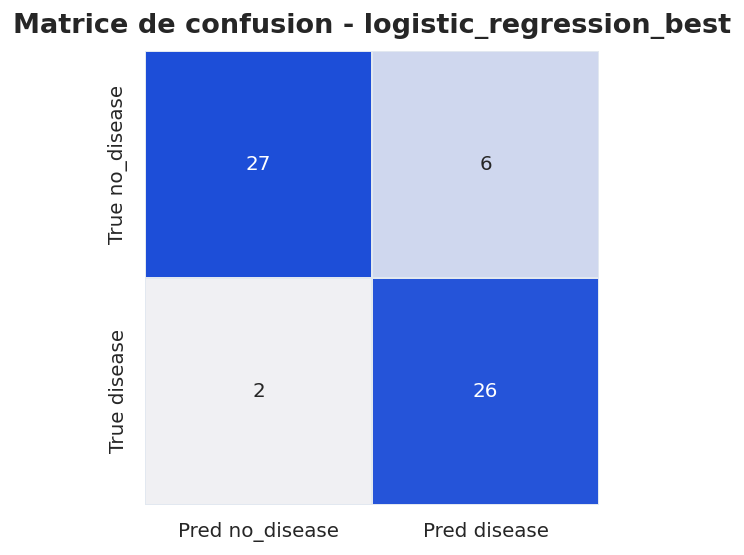

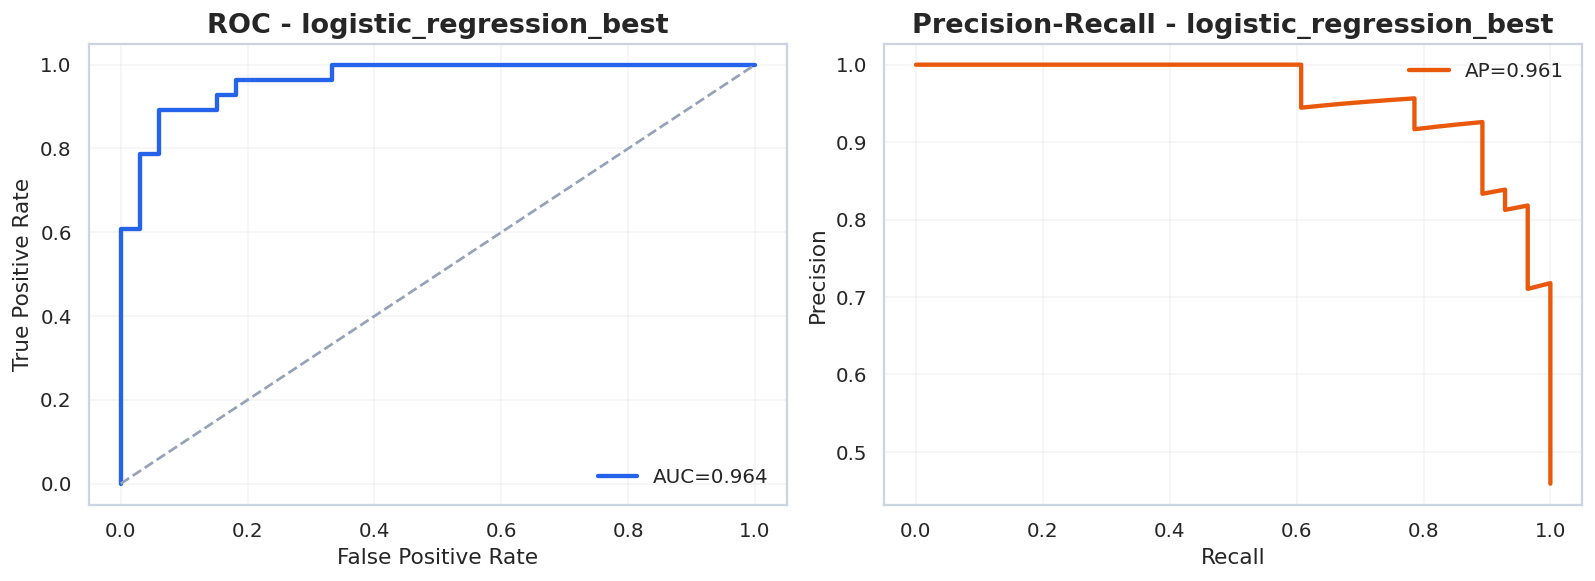

Interpretation - logistic_regression_best: performance solide; F1 test=0.867, ROC-AUC test=0.964; bonne généralisation (écart train/test maîtrisé).


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'trestbps', 'chol',
                                                    'thalach', 'oldpeak']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    OneHotEncoder(handl

In [25]:
lr_pipe = Pipeline([
    ("prep", clone(base_prep)),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

lr_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10, 50],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

lr_gs = GridSearchCV(lr_pipe, lr_grid, cv=5, scoring="f1", n_jobs=-1)
lr_gs.fit(X_train, y_train)

print("Best params LR:", lr_gs.best_params_)
print("Best CV F1 LR:", round(lr_gs.best_score_, 4))

evaluate_pipeline("logistic_regression_best", lr_gs.best_estimator_, X_train, y_train, X_test, y_test)

### Interprétation SVM
- Modèles entraînés: SVM linéaire puis SVM à noyaux (rbf/poly/sigmoid) via Grid Search.
- Analyse: comparaison de la frontière linéaire vs non-linéaire à partir des métriques test.
- Lecture pratique: le noyau améliore parfois la séparation, mais attention au risque de surapprentissage.
- Décision: choisir le SVM offrant le meilleur F1 test avec un écart train/test raisonnable.

## 6) k-NN (GridSearch, optimisation imputation, RandomizedSearch)

Best params k-NN (Grid): {'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform'}
Best CV F1 k-NN (Grid): 0.8047

===== knn_grid_best =====
Train: {'accuracy': 0.9008, 'precision': 0.8991, 'recall': 0.8829, 'f1': 0.8909, 'roc_auc': 0.9617, 'avg_precision': 0.9344}
Test : {'accuracy': 0.8689, 'precision': 0.8125, 'recall': 0.9286, 'f1': 0.8667, 'roc_auc': 0.9253, 'avg_precision': 0.8625}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61



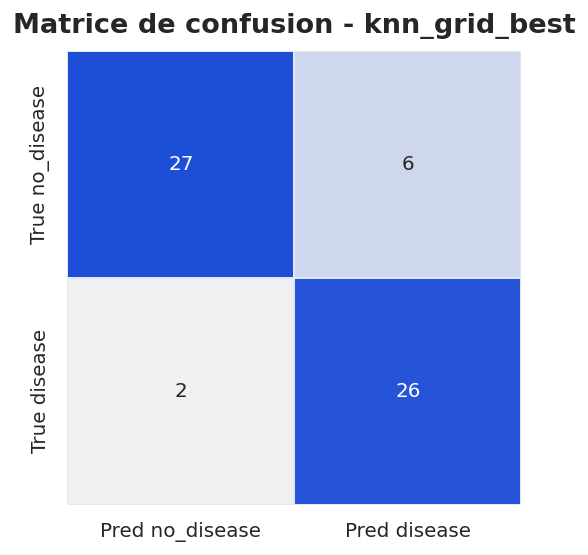

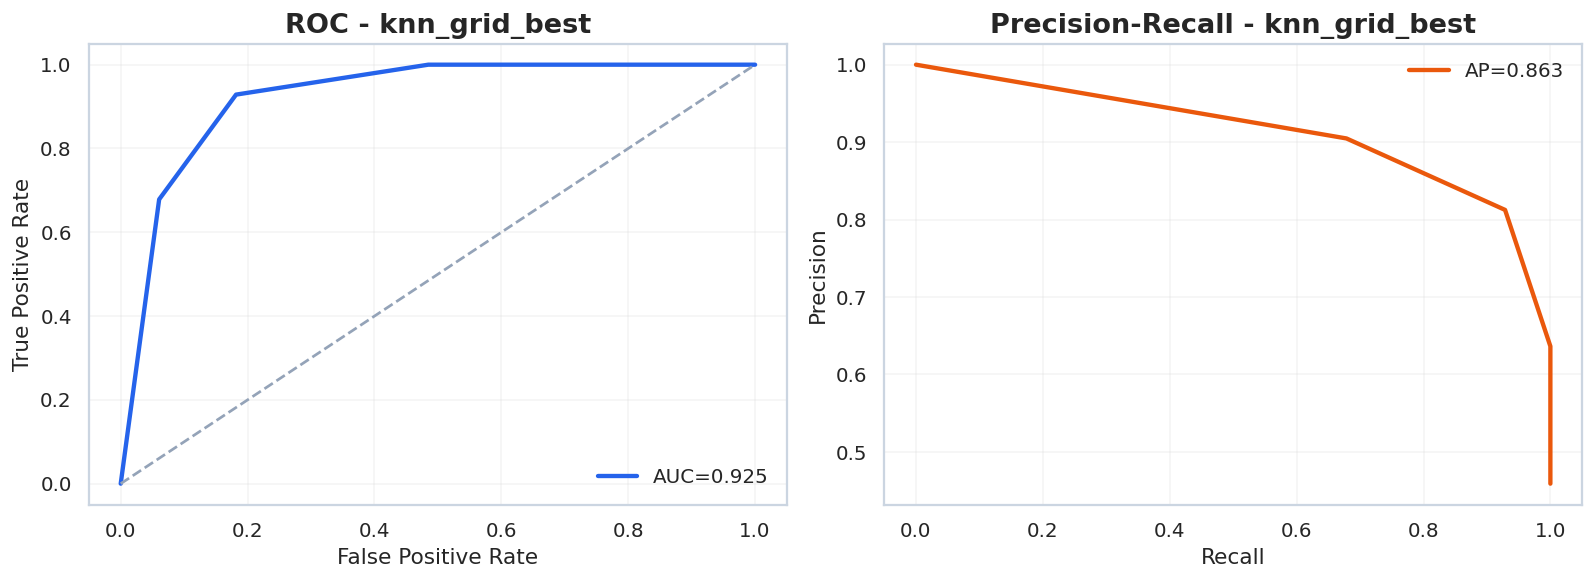

Interpretation - knn_grid_best: performance solide; F1 test=0.867, ROC-AUC test=0.925; bonne généralisation (écart train/test maîtrisé).
Best params k-NN + imputation: {'model__n_neighbors': 5, 'model__weights': 'uniform', 'prep__cat__imputer__fill_value': 0, 'prep__cat__imputer__strategy': 'most_frequent', 'prep__num__imputer__strategy': 'mean'}
Best CV F1 k-NN + imputation: 0.7976

===== knn_imputation_grid_best =====
Train: {'accuracy': 0.876, 'precision': 0.8785, 'recall': 0.8468, 'f1': 0.8624, 'roc_auc': 0.9451, 'avg_precision': 0.9202}
Test : {'accuracy': 0.8852, 'precision': 0.8621, 'recall': 0.8929, 'f1': 0.8772, 'roc_auc': 0.9529, 'avg_precision': 0.9201}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9062    0.8788    0.8923        33
           1     0.8621    0.8929    0.8772        28

    accuracy                         0.8852        61
   macro avg     0.8842    0.8858    0.8848        61
weighted avg     0.8860 

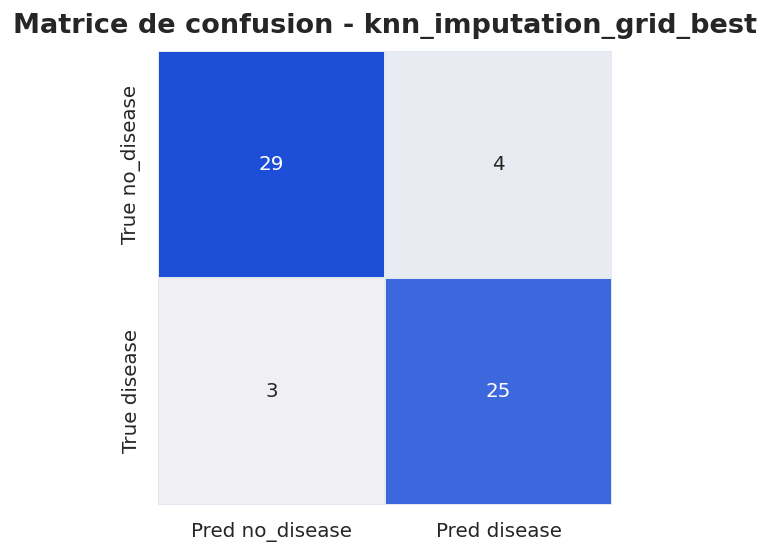

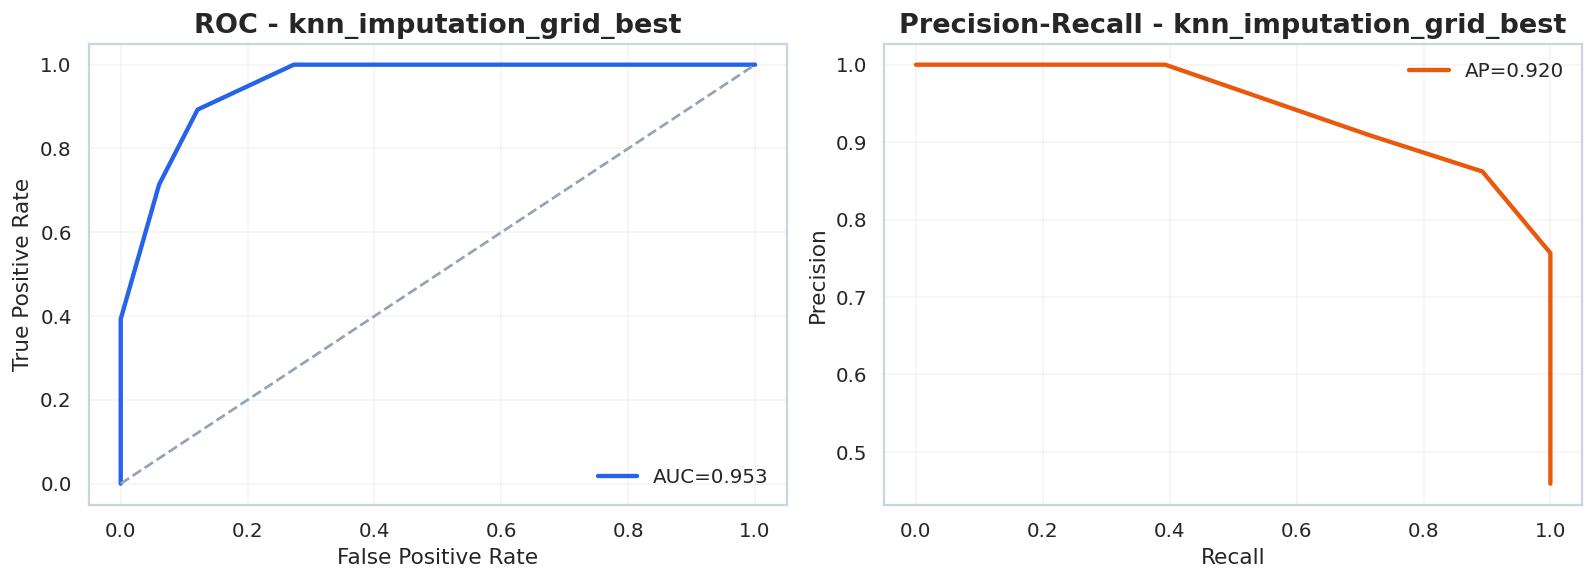

Interpretation - knn_imputation_grid_best: performance solide; F1 test=0.877, ROC-AUC test=0.953; bonne généralisation (écart train/test maîtrisé).
Best params k-NN (Randomized): {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': np.int64(7)}
Best CV F1 k-NN (Randomized): 0.8014

===== knn_randomized_best =====
Train: {'accuracy': 0.8719, 'precision': 0.8636, 'recall': 0.8559, 'f1': 0.8597, 'roc_auc': 0.9299, 'avg_precision': 0.9059}
Test : {'accuracy': 0.9016, 'precision': 0.8667, 'recall': 0.9286, 'f1': 0.8966, 'roc_auc': 0.96, 'avg_precision': 0.9347}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9355    0.8788    0.9062        33
           1     0.8667    0.9286    0.8966        28

    accuracy                         0.9016        61
   macro avg     0.9011    0.9037    0.9014        61
weighted avg     0.9039    0.9016    0.9018        61



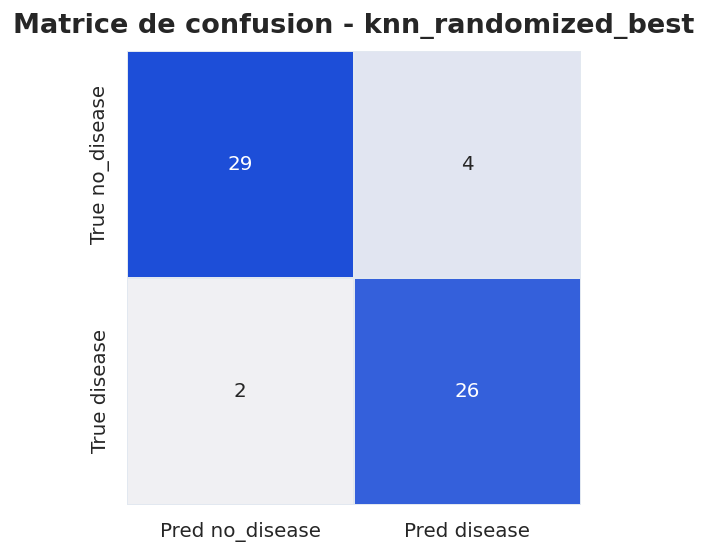

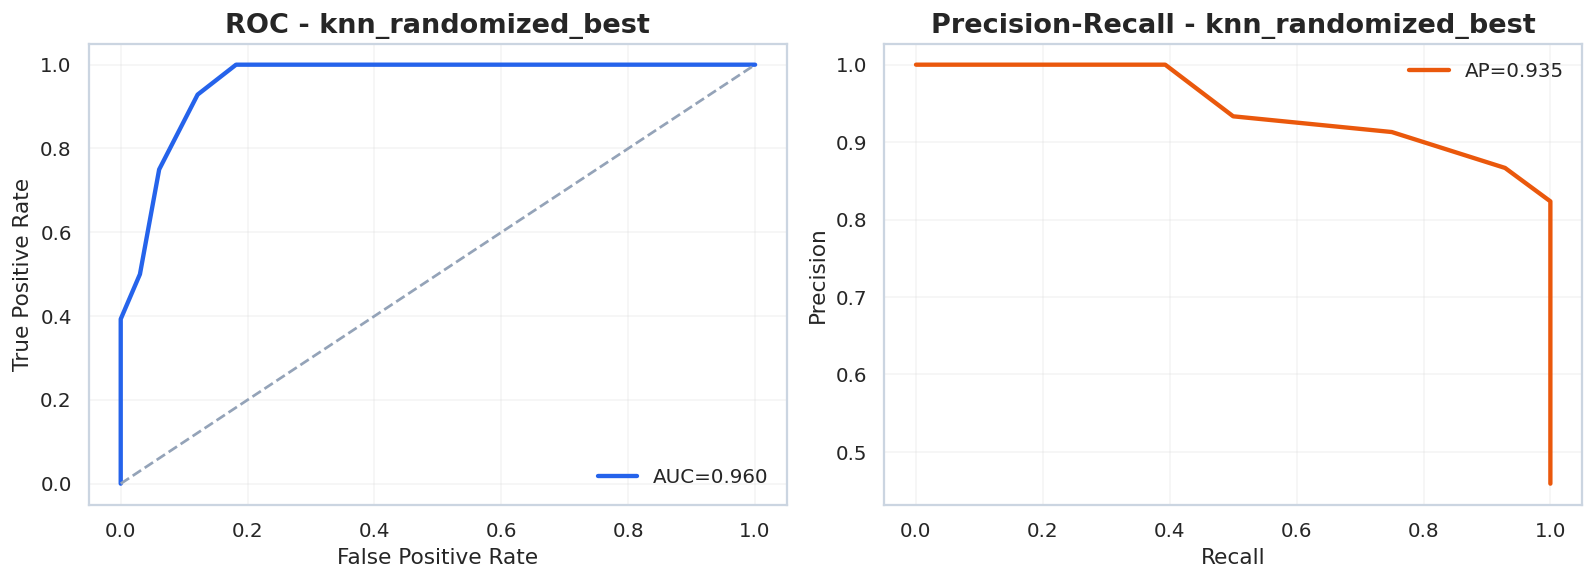

Interpretation - knn_randomized_best: performance excellente; F1 test=0.897, ROC-AUC test=0.960; test meilleur que train (possible variance d'échantillonnage).


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'trestbps', 'chol',
                                                    'thalach', 'oldpeak']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    OneHotEncoder(handl

In [26]:
knn_pipe = Pipeline([
    ("prep", clone(base_prep)),
    ("model", KNeighborsClassifier())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_gs = GridSearchCV(knn_pipe, knn_grid, cv=5, scoring="f1", n_jobs=-1)
knn_gs.fit(X_train, y_train)

print("Best params k-NN (Grid):", knn_gs.best_params_)
print("Best CV F1 k-NN (Grid):", round(knn_gs.best_score_, 4))
evaluate_pipeline("knn_grid_best", knn_gs.best_estimator_, X_train, y_train, X_test, y_test)

# Optimisation de la stratégie d'imputation
prep_tunable = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer()),
        ("scaler", StandardScaler())
    ]), NUMERIC_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer()),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), CATEGORICAL_COLS)
])

knn_tunable = Pipeline([
    ("prep", prep_tunable),
    ("model", KNeighborsClassifier())
])

impute_grid = {
    "prep__num__imputer__strategy": ["mean", "median"],
    "prep__cat__imputer__strategy": ["most_frequent", "constant"],
    "prep__cat__imputer__fill_value": [0],
    "model__n_neighbors": [5, 9, 11, 15],
    "model__weights": ["uniform", "distance"]
}

knn_impute_gs = GridSearchCV(knn_tunable, impute_grid, cv=5, scoring="f1", n_jobs=-1)
knn_impute_gs.fit(X_train, y_train)

print("Best params k-NN + imputation:", knn_impute_gs.best_params_)
print("Best CV F1 k-NN + imputation:", round(knn_impute_gs.best_score_, 4))
evaluate_pipeline("knn_imputation_grid_best", knn_impute_gs.best_estimator_, X_train, y_train, X_test, y_test)

# Randomized Search
knn_dist = {
    "model__n_neighbors": np.arange(3, 31),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_rs = RandomizedSearchCV(
    knn_pipe,
    param_distributions=knn_dist,
    n_iter=25,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
knn_rs.fit(X_train, y_train)

print("Best params k-NN (Randomized):", knn_rs.best_params_)
print("Best CV F1 k-NN (Randomized):", round(knn_rs.best_score_, 4))
evaluate_pipeline("knn_randomized_best", knn_rs.best_estimator_, X_train, y_train, X_test, y_test)

### Interprétation LDA
- Modèle entraîné avec sélection de solveur (`svd`, `lsqr`, `eigen`) et shrinkage quand applicable.
- Analyse: performances globales + stabilité numérique selon les solveurs.
- Lecture pratique: LDA est utile comme classifieur linéaire rapide et interprétable.
- Décision: conserver le solveur qui donne la meilleure qualité de généralisation.

## 7) SVM (linéaire puis noyaux avec GridSearch)

Best params SVM linéaire: {'model__C': 10, 'model__class_weight': 'balanced'}
Best CV F1 SVM linéaire: 0.8215

===== svm_linear_best =====
Train: {'accuracy': 0.876, 'precision': 0.8857, 'recall': 0.8378, 'f1': 0.8611, 'roc_auc': 0.9276, 'avg_precision': 0.9256}
Test : {'accuracy': 0.8525, 'precision': 0.7879, 'recall': 0.9286, 'f1': 0.8525, 'roc_auc': 0.96, 'avg_precision': 0.9512}

Classification report (test):
              precision    recall  f1-score   support

           0     0.9286    0.7879    0.8525        33
           1     0.7879    0.9286    0.8525        28

    accuracy                         0.8525        61
   macro avg     0.8582    0.8582    0.8525        61
weighted avg     0.8640    0.8525    0.8525        61



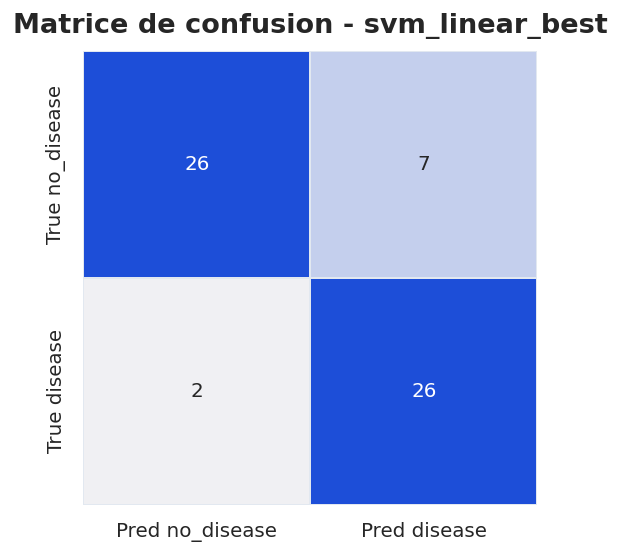

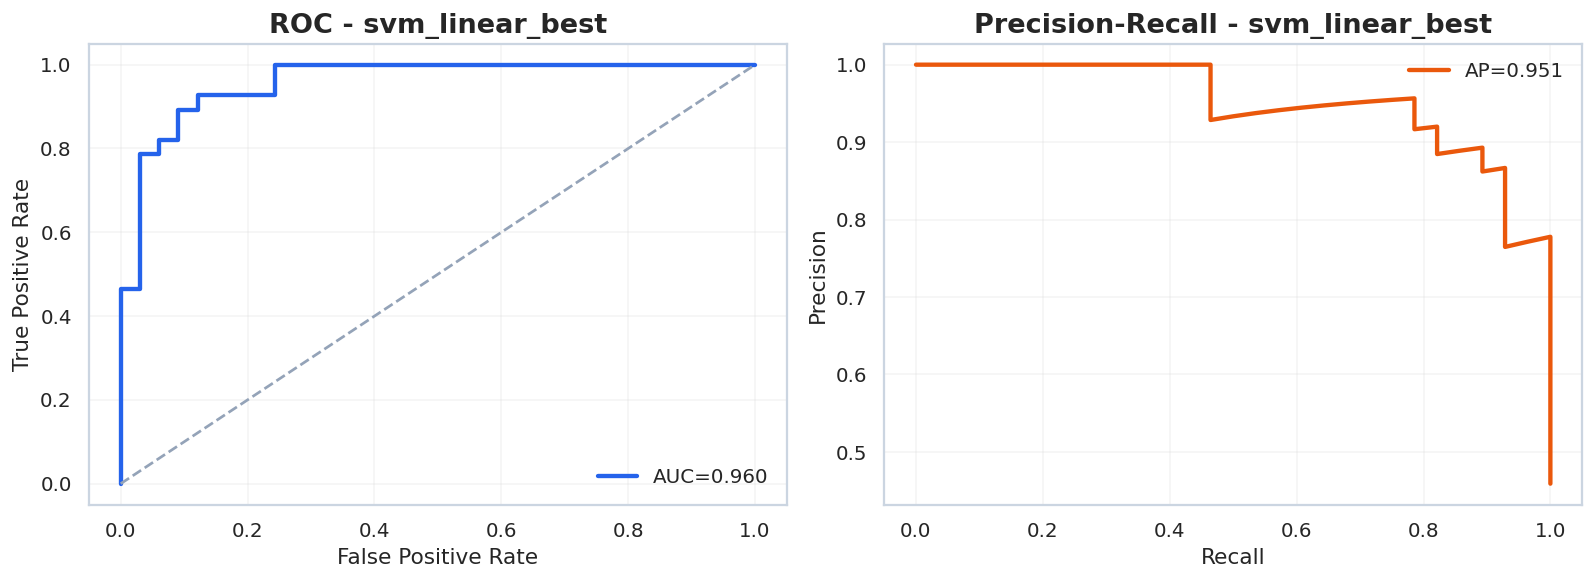

Interpretation - svm_linear_best: performance solide; F1 test=0.852, ROC-AUC test=0.960; bonne généralisation (écart train/test maîtrisé).
Best params SVM noyau: {'model__C': 1, 'model__degree': 3, 'model__gamma': 'scale', 'model__kernel': 'poly'}
Best CV F1 SVM noyau: 0.8077

===== svm_kernel_best =====
Train: {'accuracy': 0.9298, 'precision': 0.9519, 'recall': 0.8919, 'f1': 0.9209, 'roc_auc': 0.9781, 'avg_precision': 0.9756}
Test : {'accuracy': 0.8689, 'precision': 0.8571, 'recall': 0.8571, 'f1': 0.8571, 'roc_auc': 0.961, 'avg_precision': 0.9568}

Classification report (test):
              precision    recall  f1-score   support

           0     0.8788    0.8788    0.8788        33
           1     0.8571    0.8571    0.8571        28

    accuracy                         0.8689        61
   macro avg     0.8680    0.8680    0.8680        61
weighted avg     0.8689    0.8689    0.8689        61



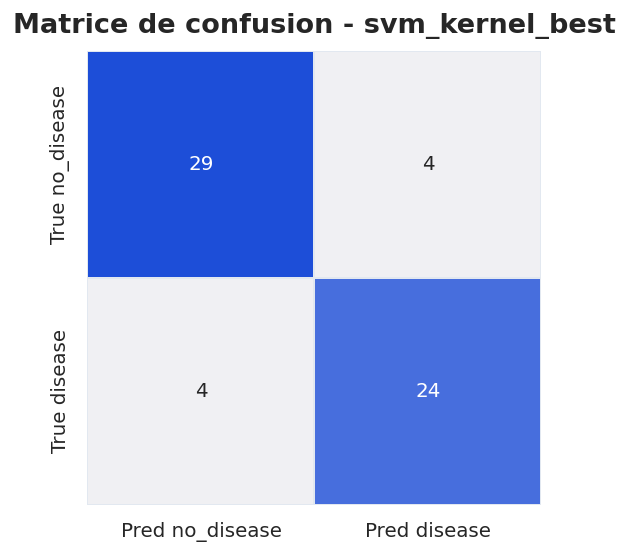

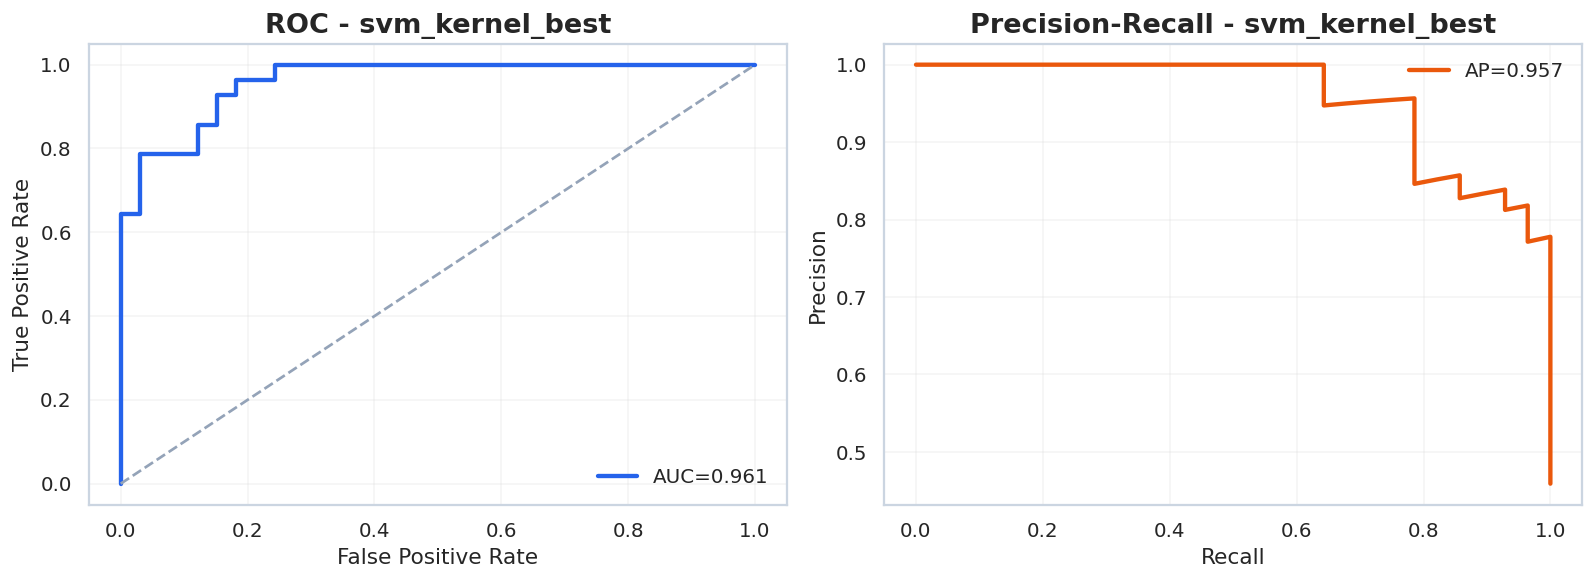

Interpretation - svm_kernel_best: performance solide; F1 test=0.857, ROC-AUC test=0.961; bonne généralisation (écart train/test maîtrisé).


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'trestbps', 'chol',
                                                    'thalach', 'oldpeak']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    OneHotEncoder(handl

In [27]:
# SVM linéaire
svm_linear = Pipeline([
    ("prep", clone(base_prep)),
    ("model", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))
])

svm_linear_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__class_weight": [None, "balanced"]
}

svm_linear_gs = GridSearchCV(svm_linear, svm_linear_grid, cv=5, scoring="f1", n_jobs=-1)
svm_linear_gs.fit(X_train, y_train)

print("Best params SVM linéaire:", svm_linear_gs.best_params_)
print("Best CV F1 SVM linéaire:", round(svm_linear_gs.best_score_, 4))
evaluate_pipeline("svm_linear_best", svm_linear_gs.best_estimator_, X_train, y_train, X_test, y_test)

# SVM à noyau
svm_kernel = Pipeline([
    ("prep", clone(base_prep)),
    ("model", SVC(probability=True, random_state=RANDOM_STATE))
])

svm_kernel_grid = [
    {"model__kernel": ["rbf"], "model__C": [0.1, 1, 10, 50], "model__gamma": ["scale", 0.01, 0.1, 1]},
    {"model__kernel": ["poly"], "model__C": [0.1, 1, 10], "model__degree": [2, 3, 4], "model__gamma": ["scale", 0.01, 0.1]},
    {"model__kernel": ["sigmoid"], "model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]}
]

svm_kernel_gs = GridSearchCV(svm_kernel, svm_kernel_grid, cv=5, scoring="f1", n_jobs=-1)
svm_kernel_gs.fit(X_train, y_train)

print("Best params SVM noyau:", svm_kernel_gs.best_params_)
print("Best CV F1 SVM noyau:", round(svm_kernel_gs.best_score_, 4))
evaluate_pipeline("svm_kernel_best", svm_kernel_gs.best_estimator_, X_train, y_train, X_test, y_test)

### Interprétation SVM
- Le SVM linéaire est robuste et souvent compétitif.
- Le SVM à noyau peut mieux capter des frontières non linéaires mais avec un risque de surapprentissage plus marqué si les hyperparamètres sont mal réglés.

## 8) LDA

Best params LDA: {'model__solver': 'svd'}
Best CV F1 LDA: 0.8118

===== lda_best =====
Train: {'accuracy': 0.8595, 'precision': 0.8738, 'recall': 0.8108, 'f1': 0.8411, 'roc_auc': 0.9287, 'avg_precision': 0.9222}
Test : {'accuracy': 0.8525, 'precision': 0.8276, 'recall': 0.8571, 'f1': 0.8421, 'roc_auc': 0.9578, 'avg_precision': 0.9534}

Classification report (test):
              precision    recall  f1-score   support

           0     0.8750    0.8485    0.8615        33
           1     0.8276    0.8571    0.8421        28

    accuracy                         0.8525        61
   macro avg     0.8513    0.8528    0.8518        61
weighted avg     0.8532    0.8525    0.8526        61



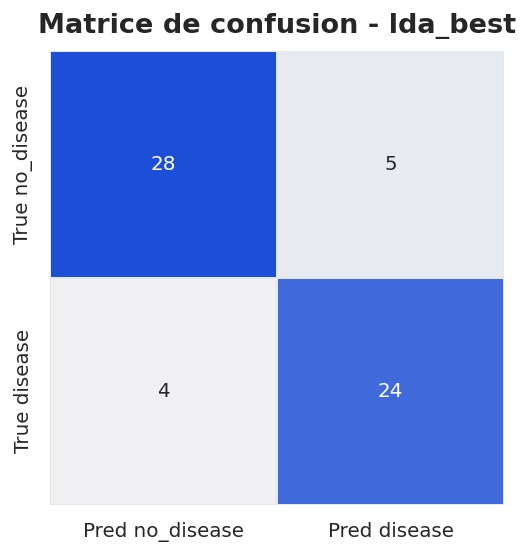

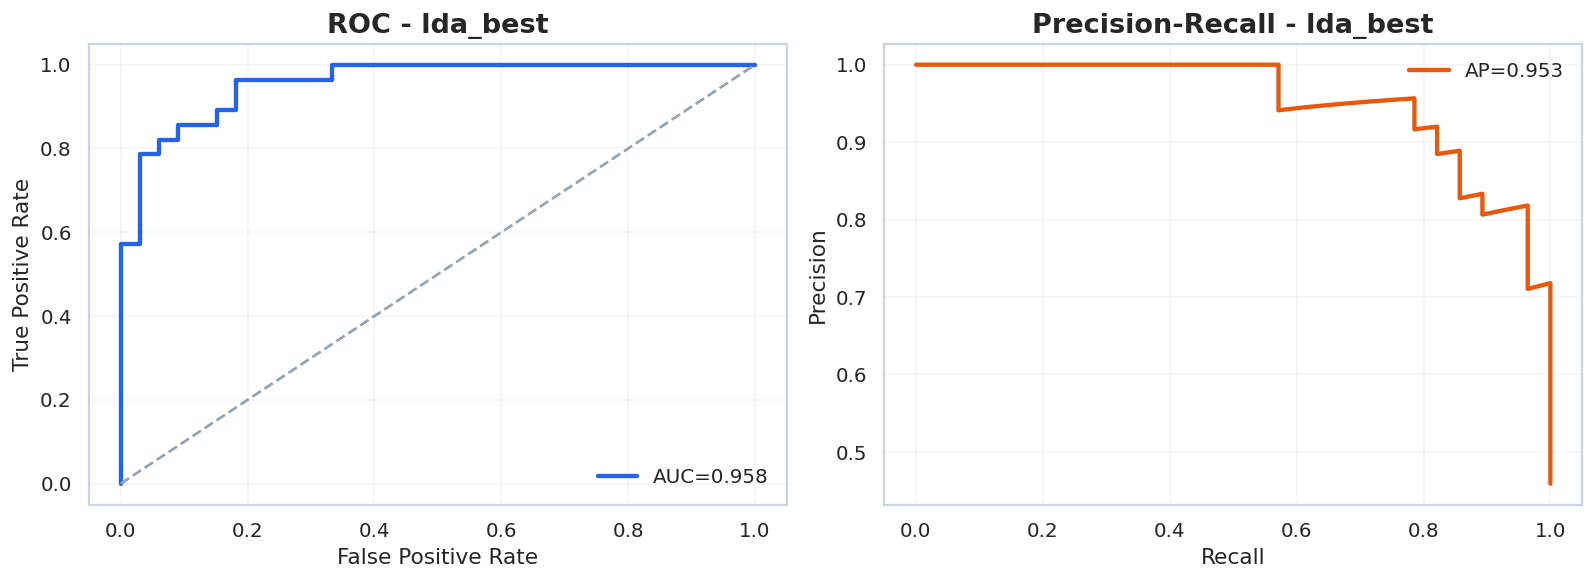

Interpretation - lda_best: performance solide; F1 test=0.842, ROC-AUC test=0.958; bonne généralisation (écart train/test maîtrisé).


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'trestbps', 'chol',
                                                    'thalach', 'oldpeak']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('onehot',
                                                                    OneHotEncoder(handl

In [28]:
lda_pipe = Pipeline([
    ("prep", clone(base_prep)),
    ("model", LinearDiscriminantAnalysis())
])

lda_grid = [
    {"model__solver": ["svd"]},
    {"model__solver": ["lsqr", "eigen"], "model__shrinkage": [None, "auto"]}
]

lda_gs = GridSearchCV(lda_pipe, lda_grid, cv=5, scoring="f1", n_jobs=-1)
lda_gs.fit(X_train, y_train)

print("Best params LDA:", lda_gs.best_params_)
print("Best CV F1 LDA:", round(lda_gs.best_score_, 4))
evaluate_pipeline("lda_best", lda_gs.best_estimator_, X_train, y_train, X_test, y_test)

### Interprétation LDA
- LDA donne généralement de bonnes performances quand les classes sont relativement séparables dans un espace linéaire transformé.
- Certains solveurs peuvent être instables numériquement selon les données, d'où l'intérêt de GridSearchCV pour sélectionner le solveur le plus fiable.

## 9) Arbre de décision + Graphviz

Best params Arbre: {'model__ccp_alpha': 0.0, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2}
Best CV F1 Arbre: 0.7516

===== decision_tree_best =====
Train: {'accuracy': 0.8554, 'precision': 0.88, 'recall': 0.7928, 'f1': 0.8341, 'roc_auc': 0.9405, 'avg_precision': 0.9263}
Test : {'accuracy': 0.8197, 'precision': 0.7931, 'recall': 0.8214, 'f1': 0.807, 'roc_auc': 0.8994, 'avg_precision': 0.8306}

Classification report (test):
              precision    recall  f1-score   support

           0     0.8438    0.8182    0.8308        33
           1     0.7931    0.8214    0.8070        28

    accuracy                         0.8197        61
   macro avg     0.8184    0.8198    0.8189        61
weighted avg     0.8205    0.8197    0.8199        61



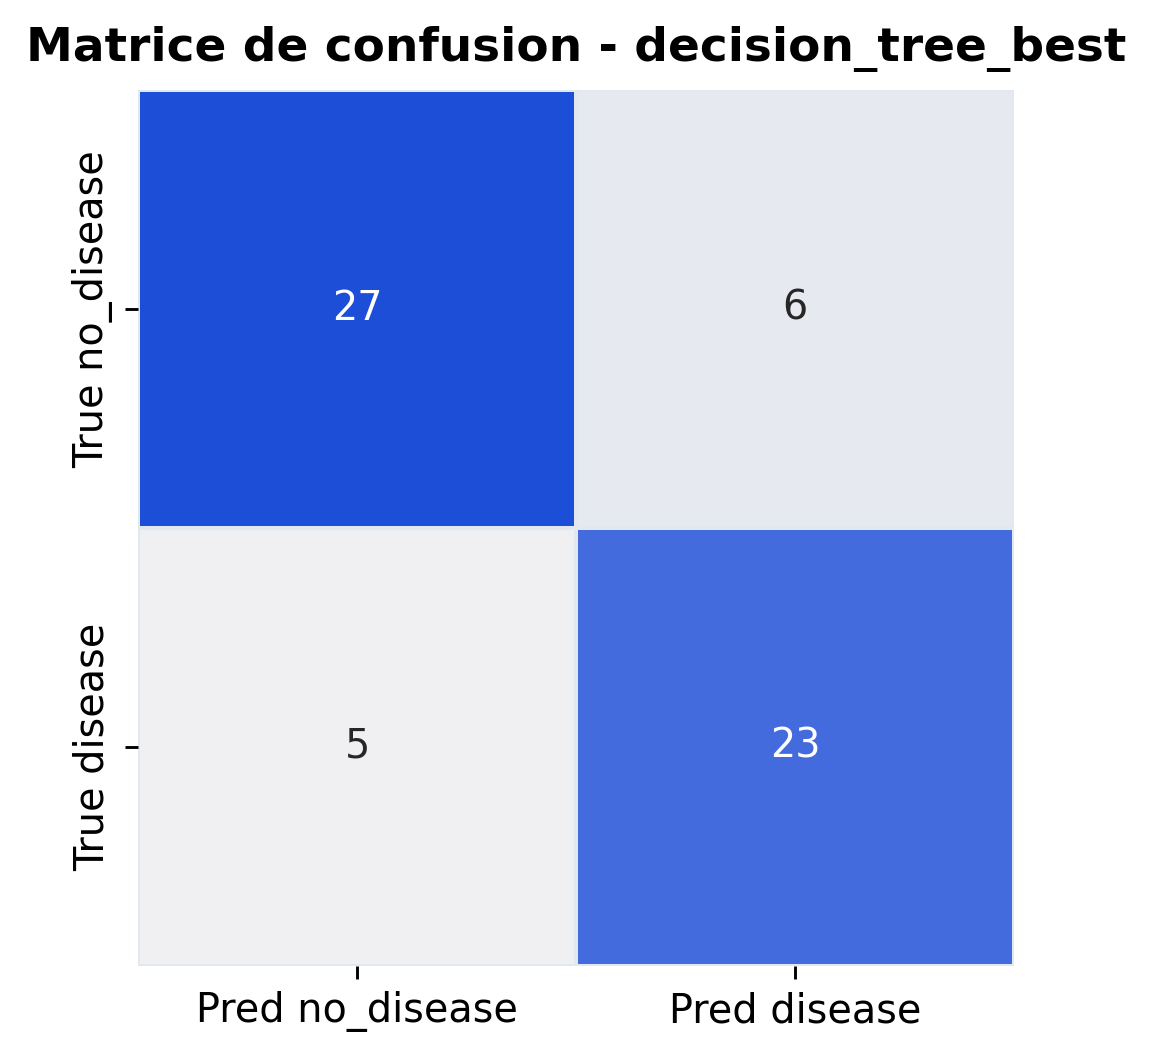

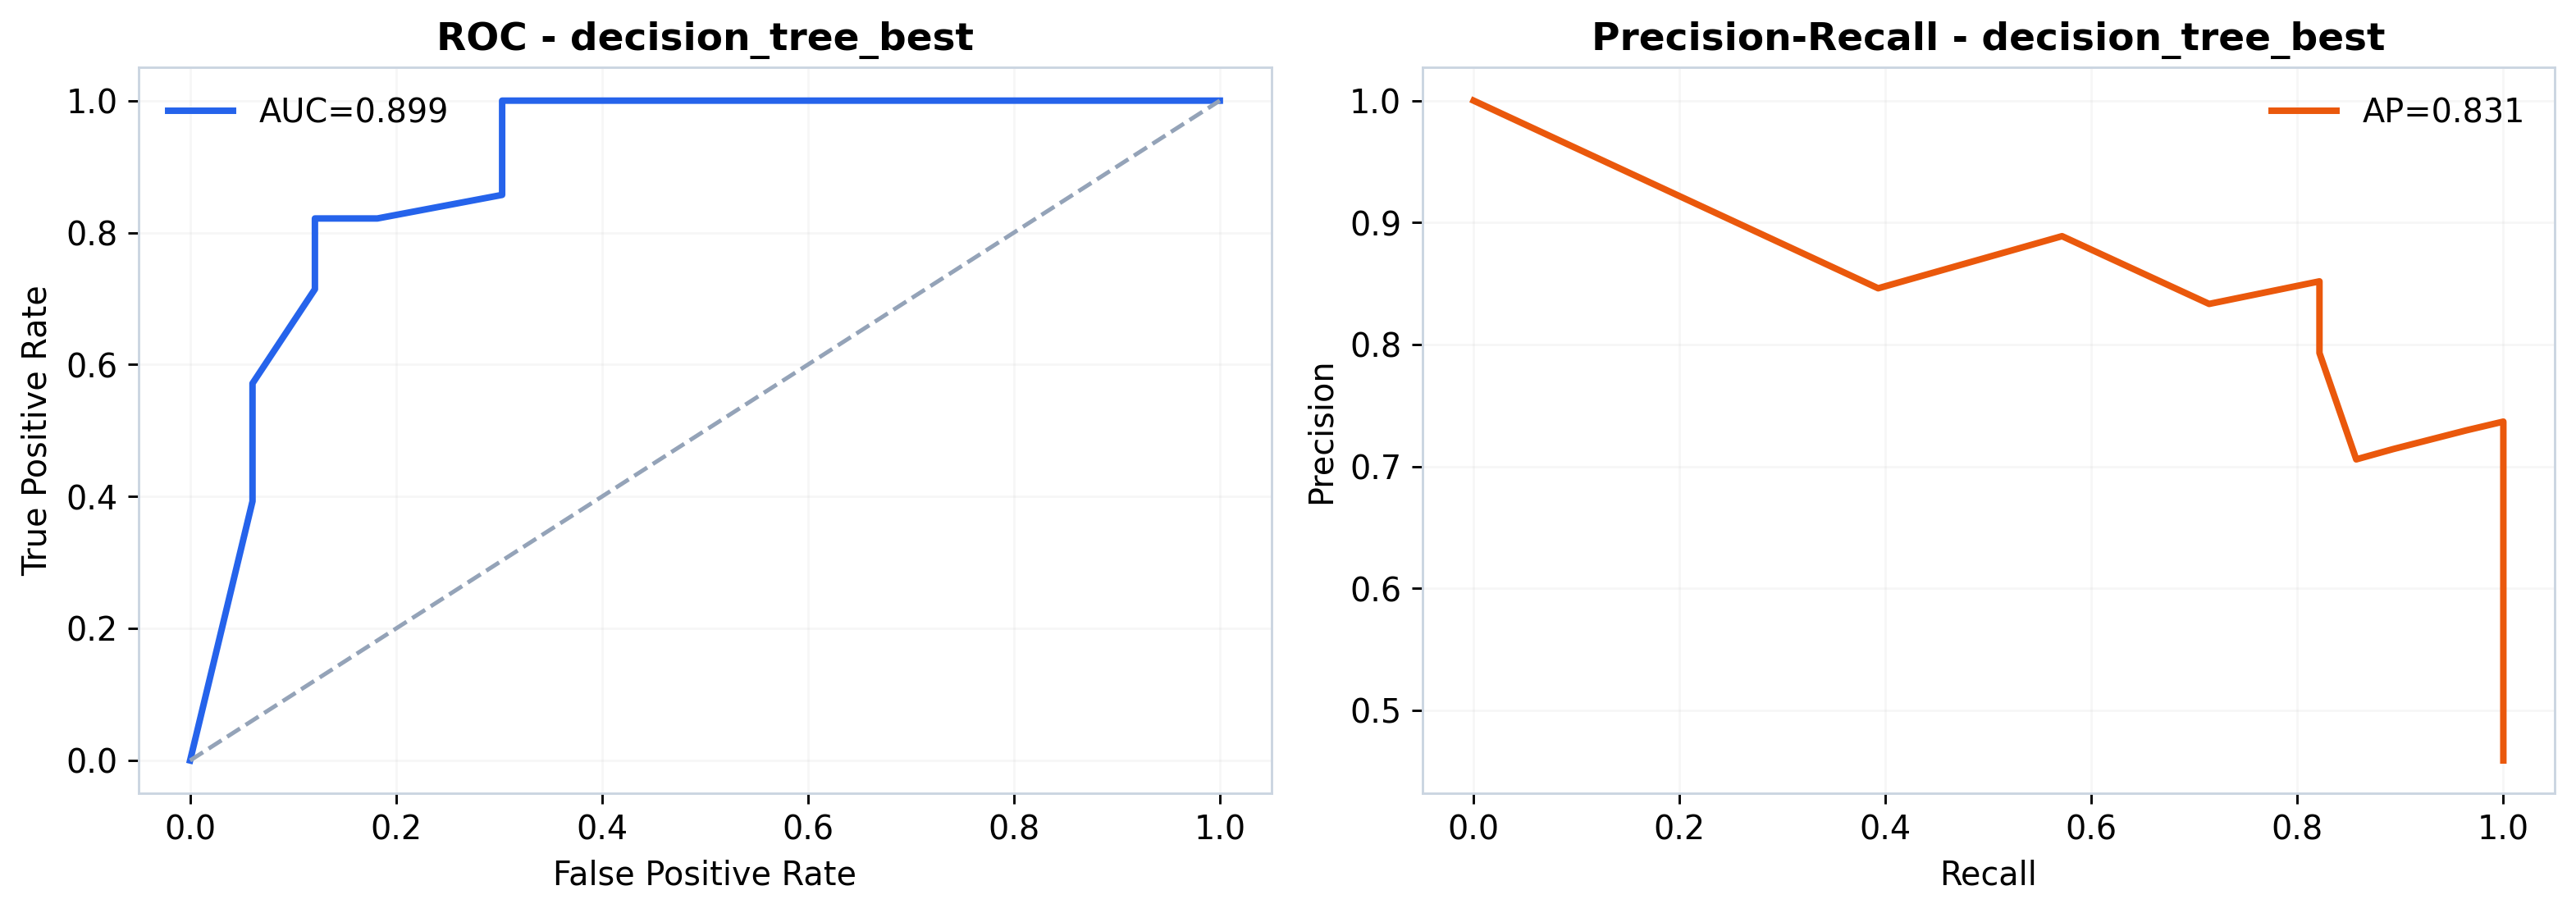

Interpretation - decision_tree_best: performance correcte; F1 test=0.807, ROC-AUC test=0.899; bonne généralisation (écart train/test maîtrisé).
Moyennes CV (Arbre):
{'test_acc': 0.7804, 'test_prec': 0.7796, 'test_rec': 0.7285, 'test_f1': 0.7516, 'test_auc': 0.8378}


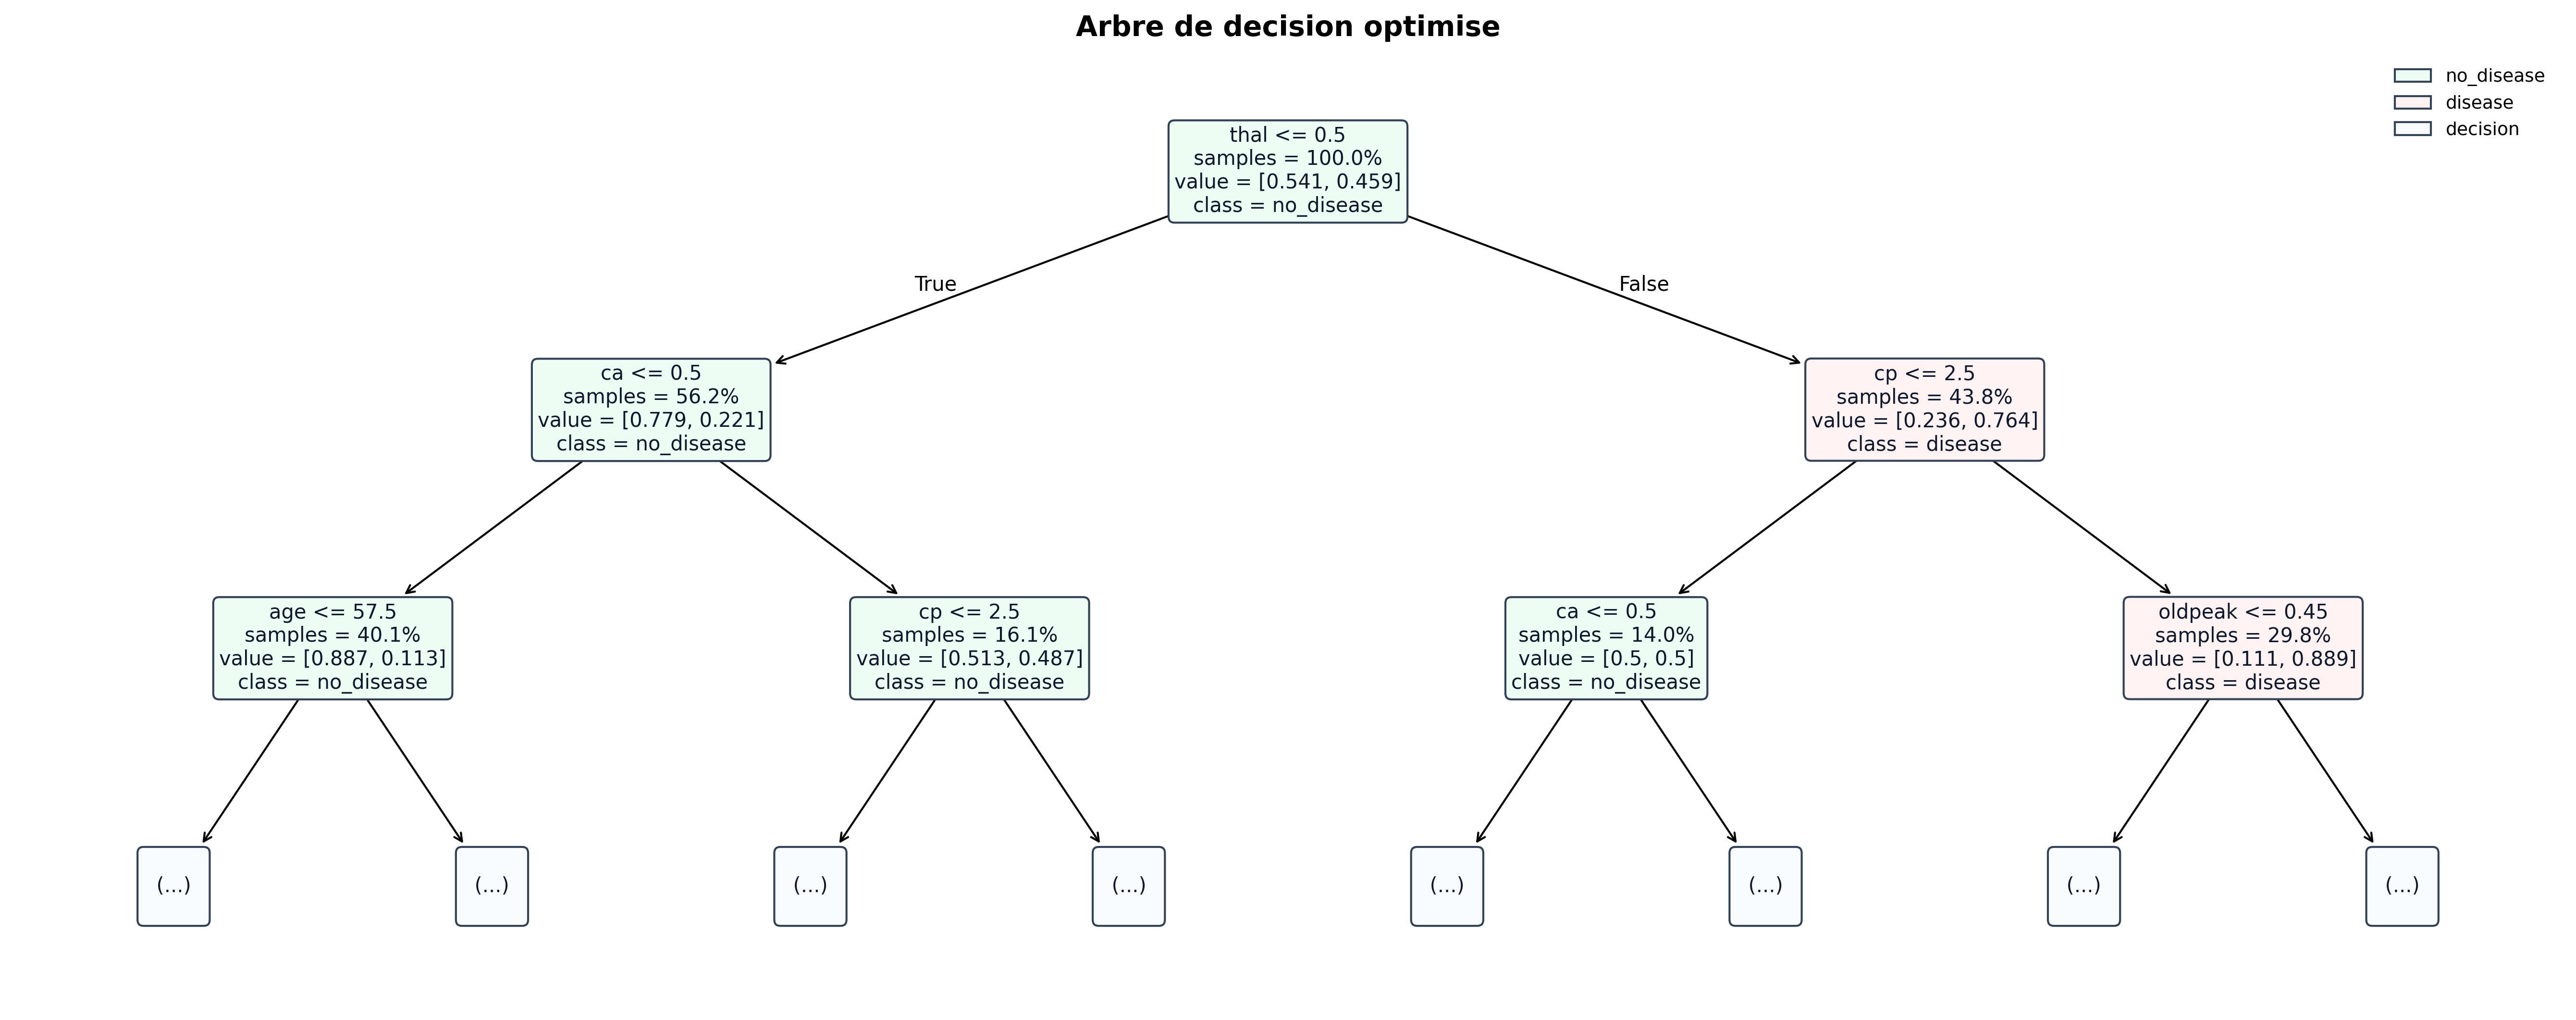

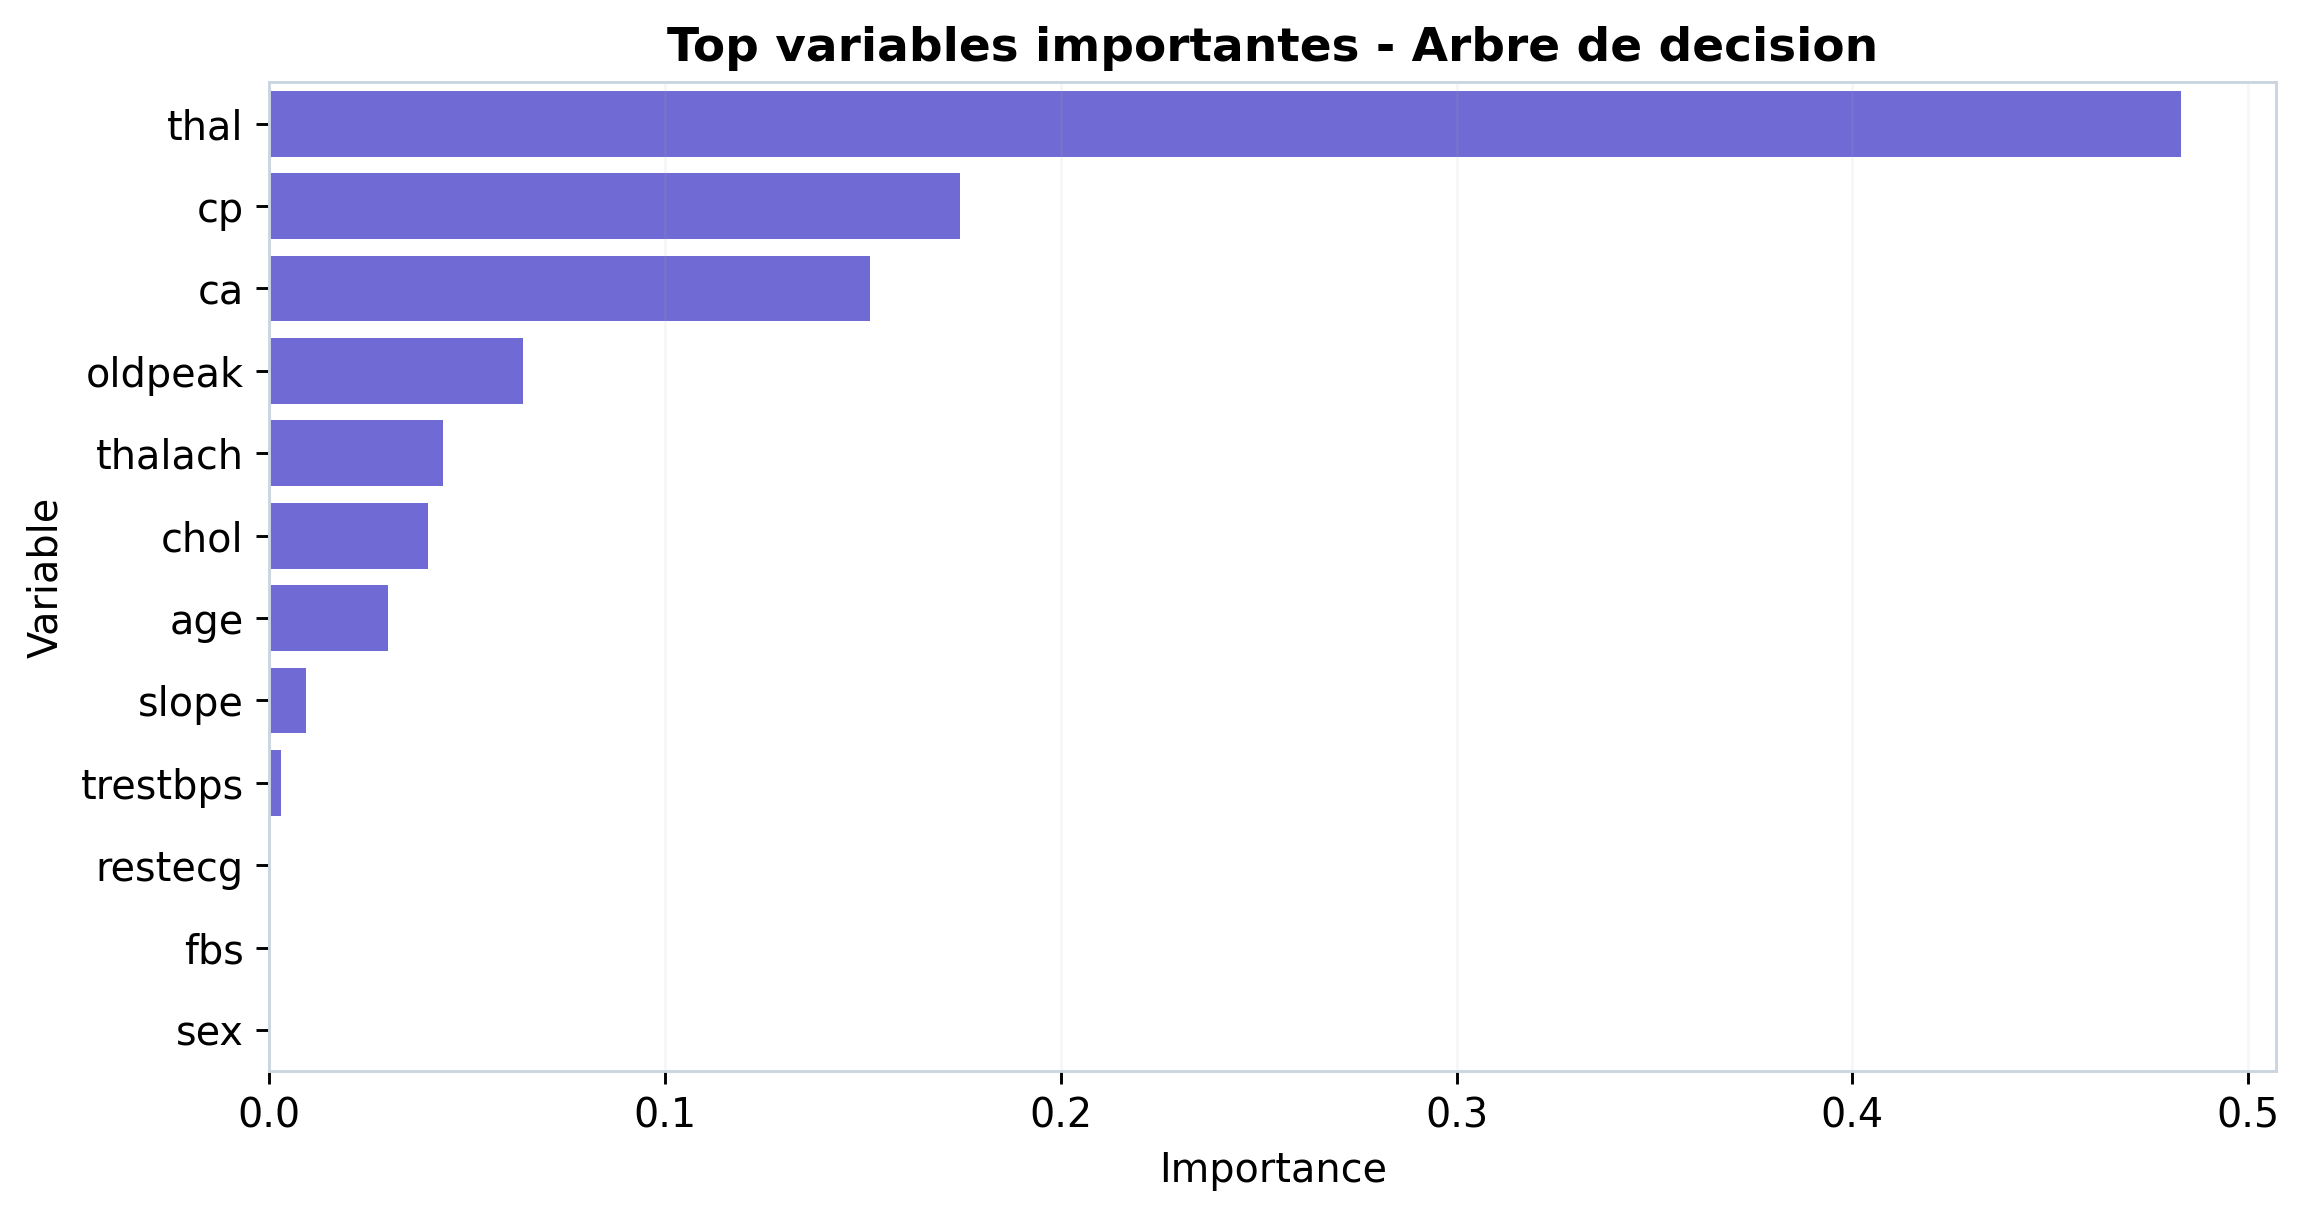

Interpretation Arbre: les variables dominantes structurent des regles decisionnelles claires, utiles pour expliquer le diagnostic.
Fichier DOT genere: outputs\trees\decision_tree_best.dot
Graphviz systeme (dot) non trouve dans PATH.
Le fichier .dot est bien genere et peut etre rendu apres installation de Graphviz.


In [40]:
# Préprocesseur adapté à l'arbre (encodage ordinal, pas de scaling nécessaire)
tree_prep = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), NUMERIC_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), CATEGORICAL_COLS)
])

tree_pipe = Pipeline([
    ("prep", tree_prep),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_grid = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [None, 3, 4, 5, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__ccp_alpha": [0.0, 0.001, 0.005, 0.01]
}

tree_gs = GridSearchCV(tree_pipe, tree_grid, cv=5, scoring="f1", n_jobs=-1)
tree_gs.fit(X_train, y_train)

print("Best params Arbre:", tree_gs.best_params_)
print("Best CV F1 Arbre:", round(tree_gs.best_score_, 4))

best_tree, _, _ = evaluate_pipeline("decision_tree_best", tree_gs.best_estimator_, X_train, y_train, X_test, y_test)

cv_scores = cross_validate(
    best_tree, X_train, y_train, cv=5,
    scoring={"acc": "accuracy", "prec": "precision", "rec": "recall", "f1": "f1", "auc": "roc_auc"},
    n_jobs=-1
)

print("Moyennes CV (Arbre):")
print({k: round(float(np.mean(v)), 4) for k, v in cv_scores.items() if k.startswith("test_")})

# Rendu visuel de l'arbre: compact, lisible, propre
feature_names = best_tree.named_steps["prep"].get_feature_names_out()
pretty_feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
model = best_tree.named_steps["model"]

fig, ax = plt.subplots(figsize=(18, 7.2), dpi=150, facecolor="white")
ax.set_facecolor("white")

artists = plot_tree(
    model,
    feature_names=pretty_feature_names,
    class_names=["no_disease", "disease"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=2,
    impurity=False,
    proportion=True,
    ax=ax
)

for ann in artists:
    text = ann.get_text()
    box = ann.get_bbox_patch()
    if box is None:
        continue

    if "class = no_disease" in text:
        box.set_facecolor("#ECFDF3")
    elif "class = disease" in text:
        box.set_facecolor("#FEF2F2")
    else:
        box.set_facecolor("#F8FAFC")

    box.set_edgecolor("#334155")
    box.set_linewidth(1.0)
    ann.set_color("#0F172A")
    ann.set_fontsize(10)

legend_items = [
    mpatches.Patch(facecolor="#ECFDF3", edgecolor="#334155", label="no_disease"),
    mpatches.Patch(facecolor="#FEF2F2", edgecolor="#334155", label="disease"),
    mpatches.Patch(facecolor="#F8FAFC", edgecolor="#334155", label="decision")
]

ax.legend(handles=legend_items, loc="upper right", frameon=False, fontsize=9)
ax.set_title("Arbre de decision optimise", fontsize=14, weight="semibold", pad=8)
ax.axis("off")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "tree_presentation.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()

# Importance des variables
importances = pd.Series(model.feature_importances_, index=pretty_feature_names).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=130, facecolor="white")
ax.set_facecolor("white")
sns.barplot(x=importances.values, y=importances.index, color="#4F46E5", alpha=0.9, ax=ax)
ax.set_title("Top variables importantes - Arbre de decision", fontsize=13, weight="semibold")
ax.set_xlabel("Importance")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.10)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "tree_feature_importance.png", dpi=200, facecolor="white", bbox_inches="tight")
plt.show()

print("Interpretation Arbre: les variables dominantes structurent des regles decisionnelles claires, utiles pour expliquer le diagnostic.")

# Export Graphviz DOT + rendu si binaire dot disponible
import shutil

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=pretty_feature_names,
    class_names=["no_disease", "disease"],
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=True,
    precision=2,
    impurity=False
)

dot_path = TREES_DIR / "decision_tree_best.dot"
dot_path.write_text(dot_data, encoding="utf-8")
print("Fichier DOT genere:", dot_path)

if shutil.which("dot"):
    g = graphviz.Source(dot_data)
    display(g)
    png_path = g.render(filename="decision_tree_best", directory=str(TREES_DIR), format="png", cleanup=True)
    print("PNG Graphviz genere:", png_path)
else:
    print("Graphviz systeme (dot) non trouve dans PATH.")
    print("Le fichier .dot est bien genere et peut etre rendu apres installation de Graphviz.")

### Interprétation Arbre de décision
- Modèle entraîné et optimisé par `GridSearchCV` (profondeur, feuilles, critère, élagage `ccp_alpha`).
- Rendu visuel amélioré: arbre lisible (depth limitée), légende de classes, importance des variables, export Graphviz.
- Lecture pratique: l'arbre donne des règles décisionnelles explicites, utiles pour expliquer les prédictions.
- Décision: à privilégier si la priorité est l'interprétabilité, même si un autre modèle a un F1 légèrement supérieur.

## 10) Comparaison finale des modèles

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
0,mixed_nb_external_module,0.901639,0.843750,0.964286,0.900000,0.977273,0.974024
1,knn_randomized_best,0.901639,0.866667,0.928571,0.896552,0.959957,0.934703
2,knn_imputation_grid_best,0.885246,0.862069,0.892857,0.877193,0.952922,0.920087
3,knn_grid_best,0.868852,0.812500,0.928571,0.866667,0.925325,0.862525
4,logistic_regression_best,0.868852,0.812500,0.928571,0.866667,0.964286,0.960881
5,svm_kernel_best,0.868852,0.857143,0.857143,0.857143,0.961039,0.956802
6,svm_linear_best,0.852459,0.787879,0.928571,0.852459,0.959957,0.951246
7,lda_best,0.852459,0.827586,0.857143,0.842105,0.957792,0.953433
8,categorical_nb_qualitative_only,0.852459,0.827586,0.857143,0.842105,0.950216,0.949218
9,gaussian_nb_numeric_only,0.819672,0.774194,0.857143,0.813559,0.861472,0.871959


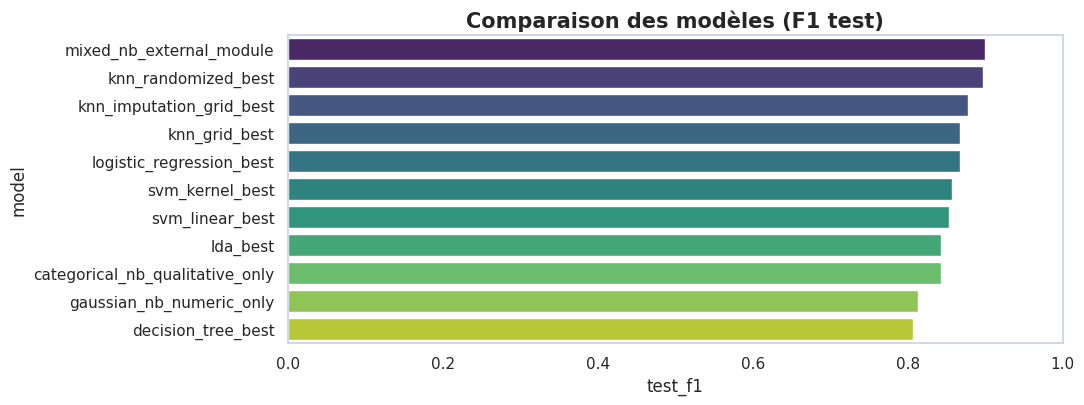

In [30]:
results_df = pd.DataFrame(all_results)

display(
    results_df[["model", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_avg_precision"]]
    .sort_values(by="test_f1", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 4))
tmp = results_df.sort_values("test_f1", ascending=False)
sns.barplot(data=tmp, x="test_f1", y="model", palette="viridis")
plt.title("Comparaison des modèles (F1 test)")
plt.xlim(0, 1)
plt.show()

## Conclusion générale (rendu final)
- Tous les algorithmes demandés sont implémentés, entraînés et analysés dans l'ordre du TP.
- Chaque modèle est évalué avec des métriques classiques, matrice de confusion, courbes ROC/PR et interprétation.
- Le rendu de l'arbre est professionnalisé (lisibilité, légende, importance des variables, export Graphviz).
- Le meilleur modèle final se choisit selon la priorité du TP: F1 test, ROC-AUC et stabilité train/test.

Conseil de remise: présenter le tableau comparatif final + justifier le modèle retenu avec 2 arguments (performance + interprétabilité).